# ECG TXT Processing Notebook

본 노트북은 datasets 폴더의 TXT(ECG) 신호를 불러와 고역통과(2 Hz) 필터를 적용하고 시각화/심박 추정까지 일괄 처리합니다.

In [37]:
# Install optional dependencies
# !pip install neurokit2 heartpy PyEMD --quiet

In [38]:
# Section 1: Notebook Configuration and Imports
import numpy as np
import pandas as pd
from pathlib import Path
import json
from glob import glob
from typing import List, Tuple, Dict, Optional

import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.ticker import MaxNLocator

from scipy.signal import butter, sosfiltfilt, iirnotch, sosfreqz, find_peaks

try:
    from tqdm.auto import tqdm
    TQDM_AVAILABLE = True
except Exception:
    TQDM_AVAILABLE = False
    def tqdm(x, **kwargs):
        return x

# Matplotlib defaults for ECG plots (wider & taller for readability)
plt.rcParams['figure.figsize'] = (16, 7)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 12

LEADS = ['I','II','III','aVR','aVL','aVF']

In [39]:
# Section 2: Parameters (fs, filter settings, paths)
from dataclasses import dataclass

@dataclass
class Config:
    fs: float = 267.0
    # Device-like filter profile (from GUI): bandpass 2–50 Hz, order 2
    device_profile_enable: bool = True
    device_fl: float = 2.0
    device_fh: float = 50.0
    device_order: int = 2

    # Legacy/extra filters
    hp_cut: float = 2.0
    hp_order: int = 2
    notch_enable: bool = False
    notch_freq: float = 50.0  # or 60.0 depending on region
    notch_q: float = 35.0
    notch_harmonics: int = 0   # 0=only base, N=include up to Nth harmonic

    input_dir: Path = Path('datasets')  # where TXT files live
    output_dir: Path = Path('out')
    auto_best_window: bool = True

    # Display controls (set to device-like band by default)
    display_target_fs: float = 120.0
    default_view_dur: float = 8.0  # wider default view
    display_band_lo: float = 2.0
    display_band_hi: float = 50.0

    # Detection controls (keep QRS-focused band)
    detect_band_lo: float = 5.0
    detect_band_hi: float = 20.0
    detect_order: int = 2
    detect_min_hr: float = 35.0
    detect_max_hr: float = 180.0
    detect_min_rr_sec: float = 0.33
    detect_prom_scale: float = 0.6
    detect_width_lo_s: float = 0.04
    detect_width_hi_s: float = 0.20
    detect_rel_height: float = 0.5
    detect_use_pca_composite: bool = False

    # Optional denoise stages
    baseline_mode: str = 'none'   # 'none' | 'median_ma'
    baseline_median_ms: float = 200.0
    baseline_ma_ms: float = 600.0

    hampel_enable: bool = False
    hampel_window_ms: float = 120.0
    hampel_k: float = 3.0

    wavelet_enable: bool = False
    wavelet_family: str = 'db4'
    wavelet_level: int = 5
    wavelet_soft: bool = True

    # NEW: Optional HeartPy noise reduction stage
    heartpy_enable: bool = False
    heartpy_cutoff: float = 0.05  # default cutoff for moving average (as fraction of fs)

    # NEW: Optional EMD/EEMD denoise
    emd_enable: bool = False
    emd_mode: str = 'emd'  # 'emd' | 'eemd'
    emd_max_imf: int = 8
    emd_remove_first_k: int = 1  # remove high-frequency IMFs

    # NEW: Adaptive notch option
    adaptive_notch_enable: bool = False
    adaptive_min_freq: float = 48.0
    adaptive_max_freq: float = 62.0
    adaptive_q: float = 35.0

    # NEW: SWT options (denoise + detector)
    swt_denoise_enable: bool = False
    swt_wavelet: str = 'coif2'
    swt_level: int = 4
    swt_fixed_thr: float = 0.5
    swt_mode: str = 'hard'  # 'hard' | 'soft'
    swt_max_level: int = 6
    swt_use_levels: object = None  # Optional[List[int]]; kept generic to avoid typing runtime
    swt_integrate_ms: int = 120
    swt_k: float = 3.0
    swt_min_rr_ms: int = 250
    swt_refine_win_ms: int = 80
    swt_target_level: object = None  # Optional[int]

cfg = Config()
cfg.output_dir.mkdir(parents=True, exist_ok=True)
(cfg.output_dir / 'signals').mkdir(parents=True, exist_ok=True)

cfg

Config(fs=267.0, device_profile_enable=True, device_fl=2.0, device_fh=50.0, device_order=2, hp_cut=2.0, hp_order=2, notch_enable=False, notch_freq=50.0, notch_q=35.0, notch_harmonics=0, input_dir=PosixPath('datasets'), output_dir=PosixPath('out'), auto_best_window=True, display_target_fs=120.0, default_view_dur=8.0, display_band_lo=2.0, display_band_hi=50.0, detect_band_lo=5.0, detect_band_hi=20.0, detect_order=2, detect_min_hr=35.0, detect_max_hr=180.0, detect_min_rr_sec=0.33, detect_prom_scale=0.6, detect_width_lo_s=0.04, detect_width_hi_s=0.2, detect_rel_height=0.5, detect_use_pca_composite=False, baseline_mode='none', baseline_median_ms=200.0, baseline_ma_ms=600.0, hampel_enable=False, hampel_window_ms=120.0, hampel_k=3.0, wavelet_enable=False, wavelet_family='db4', wavelet_level=5, wavelet_soft=True, heartpy_enable=False, heartpy_cutoff=0.05, emd_enable=False, emd_mode='emd', emd_max_imf=8, emd_remove_first_k=1, adaptive_notch_enable=False, adaptive_min_freq=48.0, adaptive_max_fre

In [40]:
# Adaptive bandpass & SQI settings
cfg.adapt_band_enable = True
cfg.adapt_window_sec = 8.0     # window length to compute artifact ratio / SQI
cfg.adapt_step_sec = 2.0       # slide step
cfg.adapt_lo_base = 0.5
cfg.adapt_hi_base = 40.0
cfg.adapt_lo_max_increase = 0.4   # how much to raise low cutoff at worst
cfg.adapt_hi_max_decrease = 10.0  # how much to lower high cutoff at worst
cfg.adapt_artifact_cap = 0.5      # artifact ratio beyond which adaptation saturates
cfg.sqi_enable = True
cfg.sqi_window_sec = 4.0
cfg.sqi_step_sec = 2.0
cfg.sqi_min_len_sec = 2.0
print('Adaptive bandpass & SQI settings added.')

Adaptive bandpass & SQI settings added.


In [41]:
# SQI & Artifact post-processing utilities
from dataclasses import dataclass

def compute_artifact_ratio_series(art_mask: np.ndarray, fs: float, win_sec: float, step_sec: float):
    if art_mask is None:
        return np.array([]), np.array([])
    win = int(round(win_sec * fs)); step = int(round(step_sec * fs))
    if win < 1: return np.array([]), np.array([])
    times = []; values = []
    for start in range(0, len(art_mask)-win+1, step):
        seg = art_mask[start:start+win]
        values.append(seg.mean())
        times.append((start+win/2)/fs)
    return np.array(times), np.array(values)


def get_or_make_sqi(filt_sig: np.ndarray, fs: float, cfg: Config):
    if not getattr(cfg, 'sqi_enable', False):
        return np.array([]), np.array([])
    sqi_t, sqi_v = compute_sqi_series(filt_sig, fs, cfg)
    return sqi_t, sqi_v


def filter_r_peaks_with_sqi(peaks: np.ndarray, sqi_t: np.ndarray, sqi_v: np.ndarray, fs: float, min_sqi: float = 0.4):
    if peaks.size == 0 or sqi_t.size == 0:
        return peaks
    # Interp SQI at peak times
    pt = peaks / fs
    sqi_interp = np.interp(pt, sqi_t, sqi_v, left=sqi_v[0], right=sqi_v[-1])
    keep = sqi_interp >= min_sqi
    return peaks[keep]

print('SQI & artifact utilities loaded.')

SQI & artifact utilities loaded.


In [42]:
# Section 3: Utility Functions (file discovery, TXT parser, multi-lead handling)
import re

def list_txt_files(input_dir: Path) -> List[Path]:
    paths = sorted(Path(input_dir).glob('*.txt'))
    return paths


def _detect_delimiter_and_header(sample_lines: List[str]) -> Tuple[str, int]:
    # Try tabs, commas, semicolons, spaces
    candidates = ['\t', ',', ';', ' ']
    delim_counts = {d: 0 for d in candidates}
    header_rows = 0
    for i, line in enumerate(sample_lines[:10]):
        # Skip empty/comment
        if not line.strip() or line.strip().startswith('#'):
            header_rows += 1
            continue
        for d in candidates:
            delim_counts[d] += line.count(d)
    delim = max(delim_counts, key=delim_counts.get)
    # Heuristic header detection: if first non-empty row has any alpha chars, mark header
    header_rows = 0
    for line in sample_lines:
        if not line.strip():
            header_rows += 1
            continue
        if re.search(r'[A-Za-z]', line):
            header_rows += 1
            continue
        break
    return delim, header_rows


def load_ecg_txt(path: Path) -> np.ndarray:
    # Read a small sample to detect delimiter/header
    with path.open('r', encoding='utf-8', errors='ignore') as f:
        sample = []
        for _ in range(5):
            try:
                sample.append(next(f))
            except StopIteration:
                break
    if not sample:
        raise ValueError(f'Empty file: {path}')
    delim, header_rows = _detect_delimiter_and_header(sample)

    # Load all using pandas for robustness
    df = pd.read_csv(path, sep=delim, header=None, skiprows=header_rows, engine='python')

    # Expect columns: [time_or_idx, I, II, III, aVR, aVL, aVF, (optional temp)]
    if df.shape[1] < 7:
        raise ValueError(f"Unexpected column count {df.shape[1]} in {path}")

    # Drop first column (index or time)
    ecg = df.iloc[:, 1:7].astype(float).to_numpy()

    # Optional temperature channel (8th col) if present
    temp = None
    if df.shape[1] >= 8:
        try:
            temp = pd.to_numeric(df.iloc[:, 7], errors='coerce').to_numpy()
        except Exception:
            temp = None

    # Replace infs with NaN then handle
    ecg = np.where(np.isfinite(ecg), ecg, np.nan)
    if np.any(np.isnan(ecg)):
        ecg_df = pd.DataFrame(ecg, columns=LEADS)
        ecg_df = ecg_df.interpolate(method='linear', limit_direction='both')
        ecg = ecg_df.to_numpy()

    # Attach temperature as attribute if present (store globally for explorer)
    if temp is not None:
        globals()['last_temp'] = temp
    return ecg


def seconds_to_samples(t: Tuple[float, float], fs: float) -> Tuple[int, int]:
    a, b = t
    return int(a * fs), int(b * fs)

In [43]:
# Plot helpers: windowing, decimation, normalization

def choose_window(total_sec: float, start_override: Optional[float], dur_override: Optional[float], default_dur: Optional[float] = None) -> Tuple[float, float]:
    if default_dur is None:
        default_dur = getattr(cfg, 'default_view_dur', 6.0)
    view_dur = dur_override if dur_override is not None else min(default_dur, total_sec)
    # default to middle of the record for readability
    default_start = max(0.0, (total_sec - view_dur) * 0.5)
    start_sec = start_override if start_override is not None else default_start
    end_sec = min(total_sec, start_sec + view_dur)
    return start_sec, end_sec


def compute_decimation(fs: float, target_fs: Optional[float] = None) -> int:
    if target_fs is None:
        target_fs = getattr(cfg, 'display_target_fs', 120.0)
    return max(1, int(round(fs / float(target_fs))))


def robust_normalize(arr: np.ndarray, axis: int = 0) -> np.ndarray:
    med = np.nanmedian(arr, axis=axis, keepdims=True)
    mad = np.nanmedian(np.abs(arr - med), axis=axis, keepdims=True)
    scaled = (arr - med) / (1.4826 * (mad + 1e-9))
    return scaled


def get_time_and_slice(n: int, fs: float, start_sec: float, end_sec: float, step: int) -> Tuple[np.ndarray, slice]:
    a, b = seconds_to_samples((start_sec, end_sec), fs)
    a = max(0, min(a, n))
    b = max(0, min(b, n))
    idxs = slice(a, b, step)
    t = np.arange(n)[idxs] / fs
    return t, idxs

# NEW: pick a window with strong QRS energy to improve visibility
from scipy.signal import sosfilt

def find_best_window(sig: np.ndarray, fs: float, dur: Optional[float] = None, lo: float = 5.0, hi: float = 20.0) -> Tuple[float, float]:
    """Return [start_sec, end_sec] where the 5–20 Hz energy is maximized on Lead II."""
    if dur is None:
        dur = getattr(cfg, 'default_view_dur', 6.0)
    if sig.size == 0:
        return 0.0, min(dur, 0.0)
    # bandpass for display energy
    lo_w = lo / (fs/2)
    hi_w = hi / (fs/2)
    bp = butter(2, [lo_w, hi_w], btype='bandpass', output='sos')
    x = sosfilt(bp, sig[:, 1])  # Lead II
    n = len(x)
    w = int(dur * fs)
    if w <= 0 or w >= n:
        return 0.0, min(dur, n/fs)
    # compute sliding energy via cumulative sum of squares for O(1) windows
    xsq = x**2
    csum = np.concatenate([[0.0], np.cumsum(xsq)])
    energies = csum[w:] - csum[:-w]
    k = int(np.argmax(energies))
    start = k / fs
    end = (k + w) / fs
    return start, end

Sample file: datasets/호진비정상.txt
Shape (samples, leads): (15275, 6)
First row: [-5.48700e+04 -3.30000e+01  5.48508e+04  2.74515e+04 -5.48536e+04
  2.74021e+04]


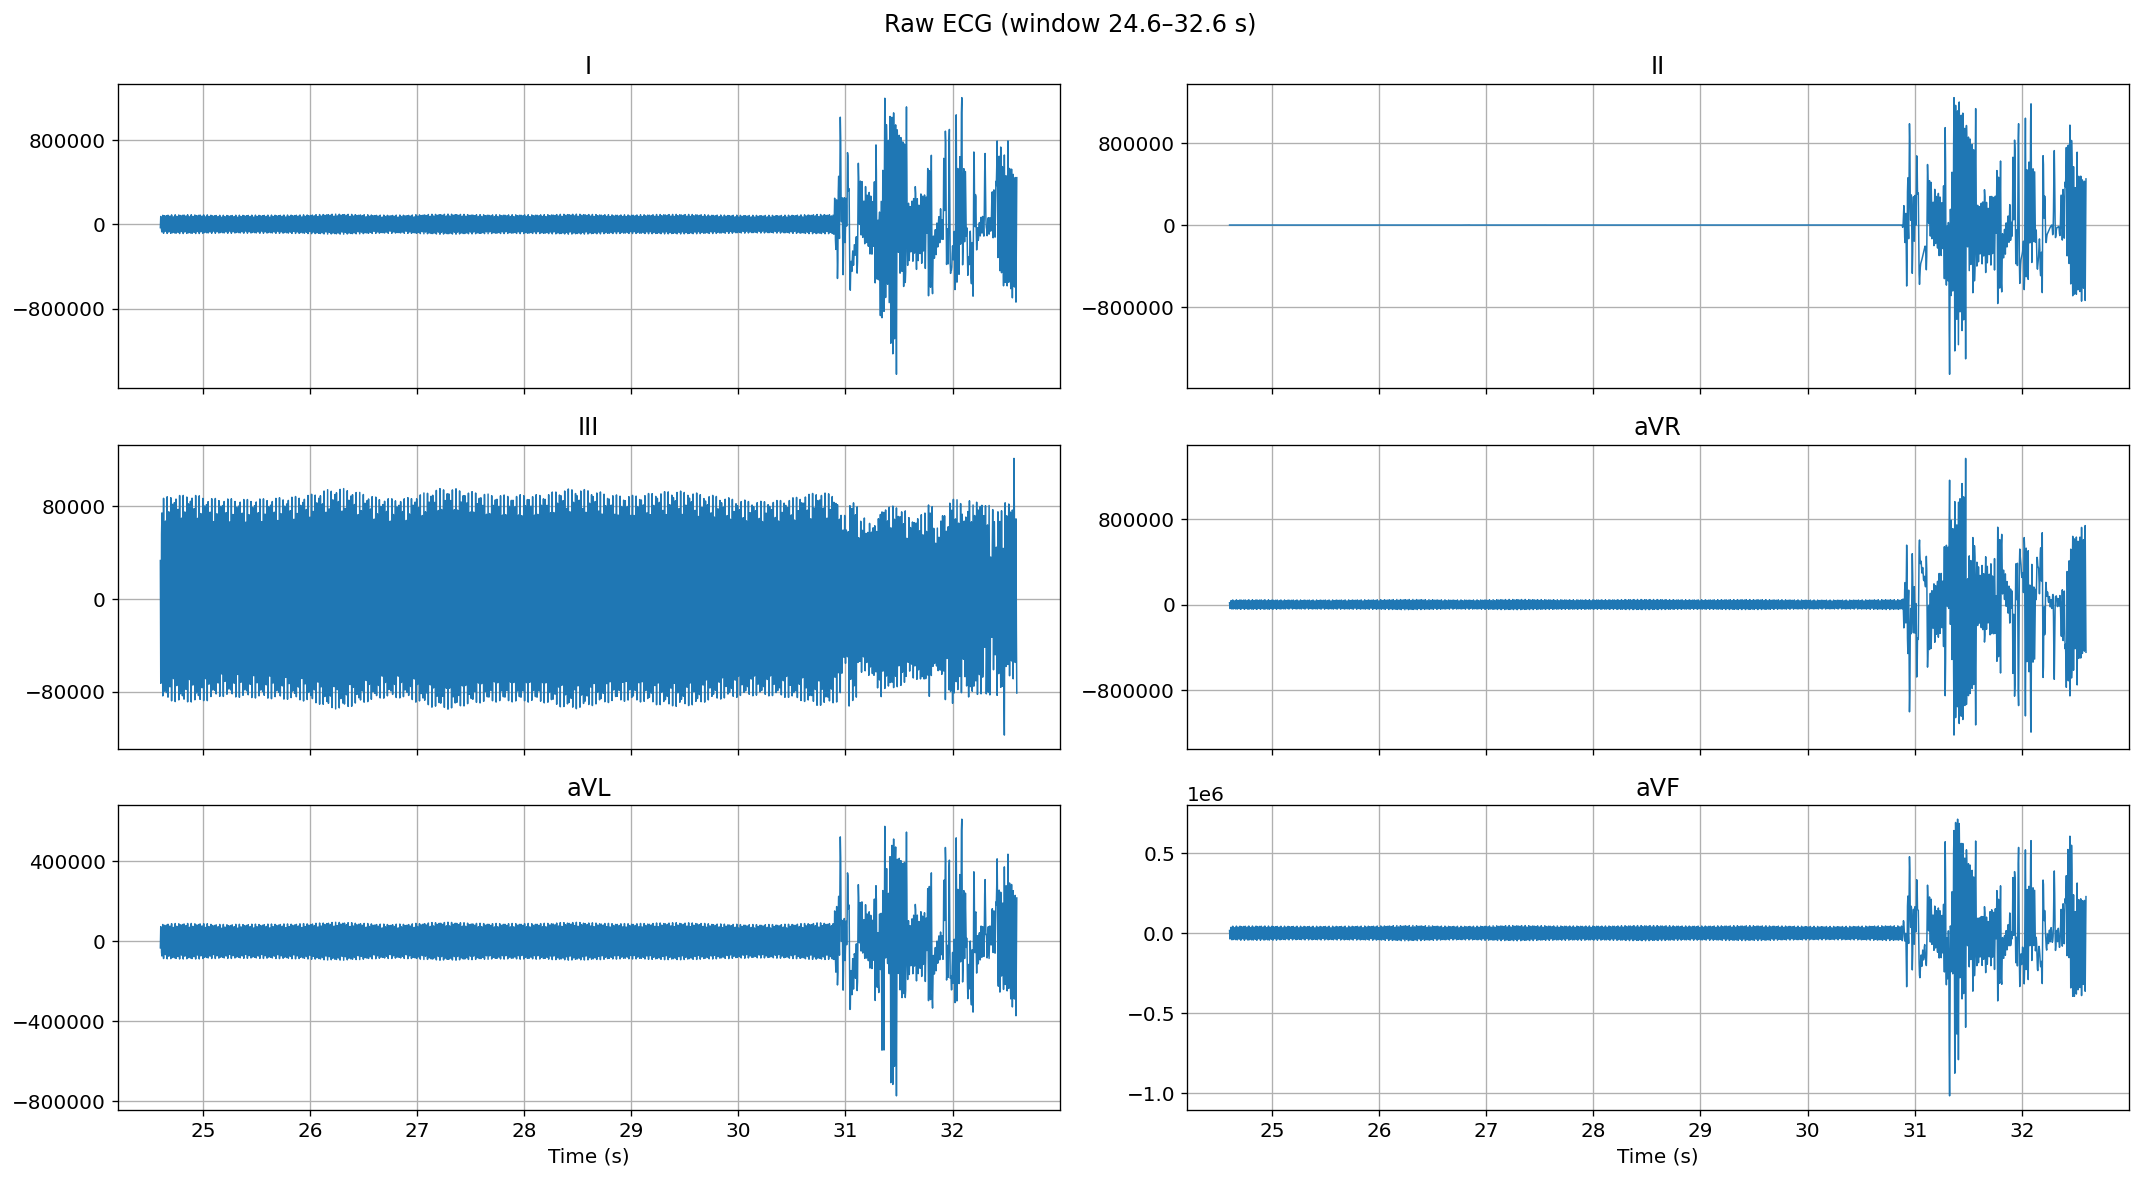

In [44]:
# Section 4: Load and Inspect a Sample ECG TXT
files = list_txt_files(cfg.input_dir)
if not files:
    print(f"No TXT files found in {cfg.input_dir.resolve()}")
else:
    sample_path = files[-1]
    print('Sample file:', sample_path)
    raw = load_ecg_txt(sample_path)
    print('Shape (samples, leads):', raw.shape)
    print('First row:', raw[0])

    total_sec = len(raw) / cfg.fs
    start_sec, end_sec = choose_window(total_sec, globals().get('custom_start_sec'), globals().get('custom_view_dur'))
    step = compute_decimation(cfg.fs, 200.0)
    t, idxs = get_time_and_slice(len(raw), cfg.fs, start_sec, end_sec, step)

    fig, axes = plt.subplots(3, 2, figsize=(18, 10), sharex=True)
    axes = axes.ravel()
    for i, lead in enumerate(LEADS):
        axes[i].plot(t, raw[idxs, i], lw=0.9)
        axes[i].set_title(lead)
        axes[i].yaxis.set_major_locator(MaxNLocator(4))
    axes[-2].set_xlabel('Time (s)')
    axes[-1].set_xlabel('Time (s)')
    fig.suptitle(f'Raw ECG (window {start_sec:.1f}–{end_sec:.1f} s)')
    plt.tight_layout()
    plt.show()

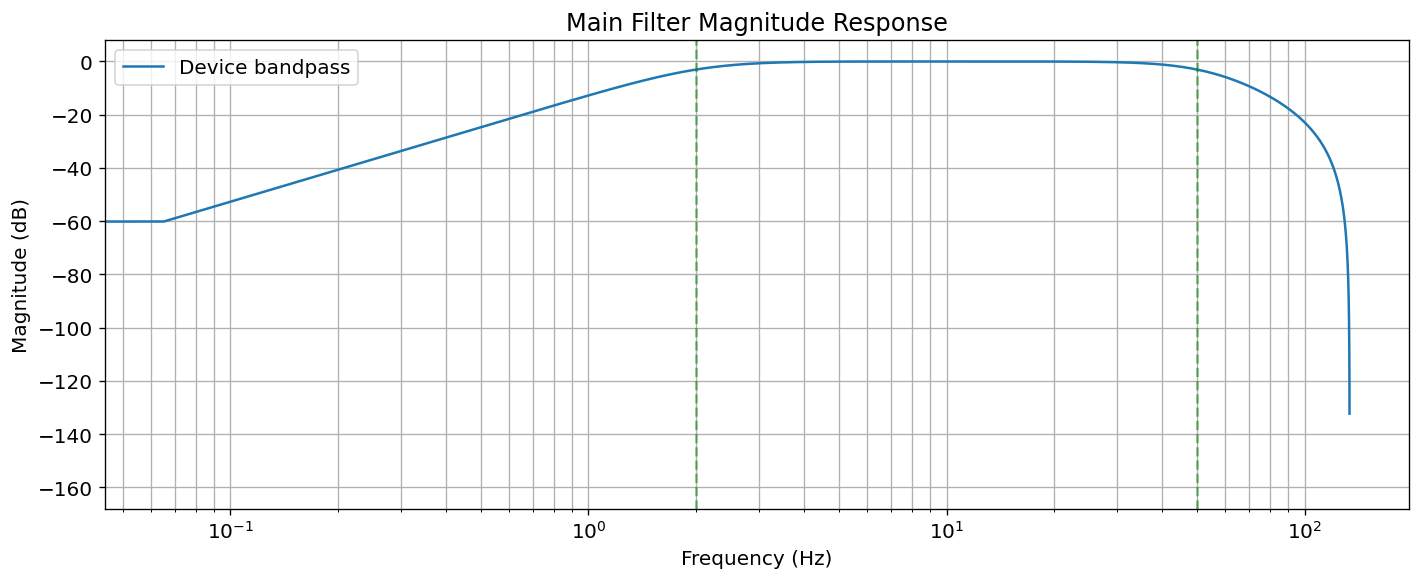

In [45]:
# Section 5: Filter Design (HP 2 Hz, optional notch)
from dataclasses import asdict

def design_highpass(fs: float, fc: float, order: int = 2):
    wn = fc / (fs / 2.0)
    sos = butter(order, wn, btype='highpass', output='sos')
    return sos


def design_bandpass(fs: float, fl: float, fh: float, order: int = 2):
    wn = [fl / (fs/2.0), fh / (fs/2.0)]
    sos = butter(order, wn, btype='bandpass', output='sos')
    return sos


def design_notch(fs: float, f0: float, q: float):
    w0 = f0 / (fs / 2.0)
    b, a = iirnotch(w0, q)
    sos = np.array([[b[0], b[1], b[2], 1.0, a[1], a[2]]])
    return sos

# Build main device-like filter SOS
if getattr(cfg, 'device_profile_enable', False):
    main_sos = design_bandpass(cfg.fs, cfg.device_fl, cfg.device_fh, cfg.device_order)
else:
    main_sos = design_highpass(cfg.fs, cfg.hp_cut, cfg.hp_order)

# Build notch stack (base + optional harmonics)
notch_sos_list = []
if cfg.notch_enable:
    for h in range(1, int(cfg.notch_harmonics) + 1 if cfg.notch_harmonics else 2):
        f0 = cfg.notch_freq * h
        if f0 < (cfg.fs / 2.0) * 0.98:
            notch_sos_list.append(design_notch(cfg.fs, f0, cfg.notch_q))

# Frequency response plot for the main filter
w, h = sosfreqz(main_sos, worN=2048, fs=cfg.fs)
plt.figure(figsize=(12,5))
plt.semilogx(w, 20*np.log10(np.maximum(np.abs(h), 1e-8)), label=('Device bandpass' if cfg.device_profile_enable else f'High-pass {cfg.hp_cut} Hz'))
if cfg.device_profile_enable:
    plt.axvline(cfg.device_fl, color='g', ls='--', alpha=0.5)
    plt.axvline(cfg.device_fh, color='g', ls='--', alpha=0.5)
else:
    plt.axvline(cfg.hp_cut, color='r', ls='--', alpha=0.5)
plt.title('Main Filter Magnitude Response')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True, which='both')
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
# Extra: Visualization improvements (bandpass view and percentile y-limits)
from scipy.signal import sosfilt

def design_bandpass(fs: float, lo: float = None, hi: float = None, order: int = 2):
    if lo is None:
        lo = getattr(cfg, 'display_band_lo', 5.0)
    if hi is None:
        hi = getattr(cfg, 'display_band_hi', 20.0)
    lo_w = lo / (fs/2)
    hi_w = hi / (fs/2)
    return butter(order, [lo_w, hi_w], btype='bandpass', output='sos')

bp_view_sos = design_bandpass(cfg.fs, cfg.display_band_lo, cfg.display_band_hi, 2)

# NEW: Optional R-peak overlay toggle
SHOW_RMARKS = True


def plot_lead_window(raw_sig: np.ndarray, filt_sig: np.ndarray, fs: float, lead_idx: int, start_sec: Optional[float]=None, dur: Optional[float]=None):
    total_sec = len(raw_sig) / fs
    start_sec, end_sec = choose_window(total_sec, start_sec, dur, default_dur=getattr(cfg, 'default_view_dur', 8.0))
    step = compute_decimation(fs, getattr(cfg, 'display_target_fs', 120.0))
    t, idxs = get_time_and_slice(len(raw_sig), fs, start_sec, end_sec, step)

    # Signals for plotting
    y_raw = raw_sig[idxs, lead_idx]
    disp = sosfilt(bp_view_sos, filt_sig[:, lead_idx])  # display-enhanced filtered
    y_flt = filt_sig[idxs, lead_idx]
    y_disp = disp[idxs]

    # Percentile-based y-limits
    r_lo, r_hi = np.nanpercentile(y_raw, [1, 99])
    f_lo, f_hi = np.nanpercentile(y_disp, [1, 99])

    # Wider figure
    fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

    # Top: Raw only
    axes[0].plot(t, y_raw, label='Raw', color='C0', alpha=0.9)
    axes[0].set_title(f'Raw - Lead {LEADS[lead_idx]}')
    axes[0].set_ylabel('Amplitude (a.u.)')
    axes[0].set_ylim(r_lo, r_hi)

    # Bottom: display band view + filtered
    axes[1].plot(t, y_disp, label=f'{cfg.display_band_lo:.0f}–{cfg.display_band_hi:.0f} Hz view', alpha=0.95, color='C3')
    axes[1].plot(t, y_flt, label='Filtered', alpha=0.6, color='C1')

    # R-peak markers computed on the same detection band for precise alignment
    if SHOW_RMARKS and 'detect_r_peaks' in globals() and lead_idx is not None:
        peaks = detect_r_peaks(
            filt_sig[:, lead_idx], fs,
            band_lo=getattr(cfg, 'detect_band_lo', 5.0),
            band_hi=getattr(cfg, 'detect_band_hi', 20.0),
            order=getattr(cfg, 'detect_order', 2),
        )
        a, b = seconds_to_samples((start_sec, end_sec), fs)
        mask = (peaks >= a) & (peaks < b)
        peaks_w = peaks[mask]
        if peaks_w.size:
            axes[1].scatter(peaks_w / fs, disp[peaks_w], c='k', s=18, label='R-peaks (detect band)', zorder=3)

    axes[1].set_title(f'Filtered + {cfg.display_band_lo:.0f}–{cfg.display_band_hi:.0f} Hz view - Lead {LEADS[lead_idx]} (window {start_sec:.1f}–{end_sec:.1f} s)')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Amplitude (a.u.)')
    axes[1].set_ylim(f_lo, f_hi)
    axes[1].legend(loc='upper right')

    plt.tight_layout()
    plt.show()


def plot_all_leads_grid(raw_sig: np.ndarray, filt_sig: np.ndarray, fs: float, start_sec: Optional[float]=None, dur: Optional[float]=None):
    total_sec = len(raw_sig) / fs
    start_sec, end_sec = choose_window(total_sec, start_sec, dur, default_dur=getattr(cfg, 'default_view_dur', 8.0))
    step = compute_decimation(fs, getattr(cfg, 'display_target_fs', 120.0))
    t, idxs = get_time_and_slice(len(raw_sig), fs, start_sec, end_sec, step)

    # Wider grid
    fig, axes = plt.subplots(3, 2, figsize=(18, 10), sharex=True)
    axes = axes.ravel()
    for i, lead in enumerate(LEADS):
        disp = sosfilt(bp_view_sos, filt_sig[:, i])
        y_disp = disp[idxs]
        p_lo, p_hi = np.nanpercentile(y_disp, [1, 99])
        axes[i].plot(t, y_disp, color='C3', alpha=0.95, label=f'{cfg.display_band_lo:.0f}–{cfg.display_band_hi:.0f} Hz view')
        axes[i].plot(t, filt_sig[idxs, i], color='C1', alpha=0.6, label='Filtered')
        if SHOW_RMARKS and 'detect_r_peaks' in globals():
            peaks = detect_r_peaks(
                filt_sig[:, i], fs,
                band_lo=getattr(cfg, 'detect_band_lo', 5.0),
                band_hi=getattr(cfg, 'detect_band_hi', 20.0),
                order=getattr(cfg, 'detect_order', 2),
            )
            a, b = seconds_to_samples((start_sec, end_sec), fs)
            mask = (peaks >= a) & (peaks < b)
            peaks_w = peaks[mask]
            if peaks_w.size:
                axes[i].scatter(peaks_w / fs, disp[peaks_w], c='k', s=12, label='R-peaks', zorder=3)
        axes[i].set_title(lead)
        axes[i].set_ylim(p_lo, p_hi)
    axes[0].legend(loc='upper right')
    axes[-1].set_xlabel('Time (s)')
    fig.suptitle(f'All Leads ({cfg.display_band_lo:.0f}–{cfg.display_band_hi:.0f} Hz view aligned R-peaks, window {start_sec:.1f}–{end_sec:.1f} s)')
    plt.tight_layout(); plt.show()

In [47]:
# Visualization: SQI & Artifact timeline helper

def plot_sqi_artifact_timeline(raw_sig: np.ndarray, filt_sig: np.ndarray, fs: float, cfg: Config,
                                sqi_t: np.ndarray, sqi_v: np.ndarray, art_mask: np.ndarray | None,
                                peaks: np.ndarray | None = None, min_sqi: float = 0.4):
    import matplotlib.pyplot as plt
    dur = len(raw_sig)/fs
    fig, axes = plt.subplots(3,1, figsize=(16,8), sharex=True)
    t = np.arange(len(raw_sig))/fs
    lead = 1 if raw_sig.shape[1] > 1 else 0
    axes[0].plot(t, raw_sig[:, lead], lw=0.6, color='C0')
    axes[0].set_ylabel('Raw')
    if art_mask is not None and art_mask.any():
        on=False; s0=0
        for i,flag in enumerate(art_mask):
            if flag and not on:
                on=True; s0=i
            if on and (not flag or i==len(art_mask)-1):
                e=i if not flag else i+1
                axes[0].axvspan(s0/fs, (e-1)/fs, color='red', alpha=0.05)
                on=False
    axes[0].set_title('Raw with artifact shading')

    axes[1].plot(sqi_t, sqi_v, marker='o', ms=3, lw=1, color='C2')
    axes[1].axhline(min_sqi, color='r', ls='--', alpha=0.5, label='SQI threshold')
    axes[1].set_ylabel('SQI')
    axes[1].set_ylim(-0.05,1.05)
    axes[1].legend()

    if art_mask is not None and art_mask.size:
        art_t, art_r = compute_artifact_ratio_series(art_mask, fs, getattr(cfg,'adapt_window_sec',8.0), getattr(cfg,'adapt_step_sec',2.0))
    else:
        art_t, art_r = np.array([]), np.array([])
    if art_t.size:
        axes[2].plot(art_t, art_r, marker='.', lw=1, color='C1')
        axes[2].set_ylabel('Artifact ratio')
    else:
        axes[2].text(0.5,0.5,'No artifact ratio data', ha='center', va='center')
    axes[2].set_xlabel('Time (s)')

    if peaks is not None and peaks.size:
        axes[0].scatter(peaks/fs, raw_sig[peaks, lead], s=12, c='k', label='R-peaks cleaned', zorder=3)
        axes[0].legend(loc='upper right')

    plt.tight_layout(); plt.show()

print('SQI timeline plotting helper loaded.')

SQI timeline plotting helper loaded.


In [48]:
# Ensure adaptive band limit function present (in case earlier cell order changed)
if '_adapt_band_limits' not in globals():
    def _adapt_band_limits(base_lo: float, base_hi: float, artifact_ratio: float, cfg: Config):
        cap = getattr(cfg, 'adapt_artifact_cap', 0.5)
        r = min(max(artifact_ratio, 0.0), cap) / cap
        lo = base_lo + r * getattr(cfg, 'adapt_lo_max_increase', 0.4)
        hi = base_hi - r * getattr(cfg, 'adapt_hi_max_decrease', 10.0)
        if hi - lo < 5.0:
            lo = max(0.4, hi - 5.0)
        return lo, max(15.0, hi)
    print('Injected fallback _adapt_band_limits definition.')

In [49]:
# Adaptive band utility functions
def _adapt_band_limits(base_lo: float, base_hi: float, artifact_ratio: float, cfg: Config):
    cap = getattr(cfg, 'adapt_artifact_cap', 0.5)
    r = min(max(artifact_ratio, 0.0), cap) / cap  # 0..1 normalized
    lo = base_lo + r * getattr(cfg, 'adapt_lo_max_increase', 0.4)
    hi = base_hi - r * getattr(cfg, 'adapt_hi_max_decrease', 10.0)
    # keep logical ordering
    lo = min(lo, hi - 5.0) if hi - lo < 5.0 else lo
    return max(0.4, lo), max(15.0, hi)

# SQI computation
def compute_sqi_window(sig: np.ndarray, fs: float) -> float:
    if sig.size < 8 or np.allclose(sig, sig[0]):
        return 0.0
    n = len(sig)
    freqs = np.fft.rfftfreq(n, 1/fs)
    spec = np.abs(np.fft.rfft(sig))**2
    total = spec.sum() + 1e-12
    def band(lo, hi):
        return spec[(freqs>=lo)&(freqs<hi)].sum()
    qrs_pw = band(5,15)
    lf_pw = band(0,0.5)
    hf_pw = band(25,40)
    psr = qrs_pw / total
    bw_idx = lf_pw / total
    hf_idx = hf_pw / total
    kurt = scipy.stats.kurtosis(sig, fisher=False, nan_policy='omit') if 'scipy' in globals() else 3.0
    sqi = (0.5*psr) + (0.2*(1-bw_idx)) + (0.2*(1-hf_idx)) + (0.1*(1/(1+abs(kurt-3))))
    return float(np.clip(sqi, 0, 1))


def compute_sqi_series(x: np.ndarray, fs: float, cfg: Config) -> tuple[np.ndarray, np.ndarray]:
    if not getattr(cfg, 'sqi_enable', False):
        return np.array([]), np.array([])
    win = int(round(cfg.sqi_window_sec * fs))
    step = int(round(cfg.sqi_step_sec * fs))
    if win < int(cfg.sqi_min_len_sec * fs):
        return np.array([]), np.array([])
    out_t = []
    out_sqi = []
    lead = x[:,1] if x.shape[1] > 1 else x[:,0]
    for start in range(0, len(lead)-win+1, step):
        seg = lead[start:start+win]
        sqi = compute_sqi_window(seg, fs)
        out_t.append((start+win/2)/fs)
        out_sqi.append(sqi)
    return np.array(out_t), np.array(out_sqi)


In [50]:
# Section 6: Process ECG (main pipeline)
from scipy.signal import butter, sosfiltfilt, iirnotch, tf2sos
import numpy as np

# Try to precompute globals if cfg is already defined; otherwise, defer to process_ecg
notch_sos_list = []
try:
    _HAS_CFG = 'cfg' in globals()
except Exception:
    _HAS_CFG = False

if _HAS_CFG:
    try:
        main_sos = butter(getattr(cfg, 'device_order', 4),
                          [cfg.device_fl/(cfg.fs/2), cfg.device_fh/(cfg.fs/2)],
                          btype='bandpass', output='sos')
        if getattr(cfg, 'notch_enable', False):
            for h in range(cfg.notch_harmonics + 1):
                f0 = cfg.notch_freq * (h+1)
                if f0 < (cfg.fs/2 - 1):
                    b, a = iirnotch(w0=f0/(cfg.fs/2), Q=cfg.notch_q)
                    notch_sos_list.append(tf2sos(b, a))
    except Exception:
        main_sos = None
else:
    main_sos = None


def process_ecg(x, fs: float, cfg) -> np.ndarray:
    x = np.asarray(x)
    if x.ndim == 1:
        x = x[:, None]
    sig = x.copy().astype(float)

    # Optional artifact pre-inpaint for continuity
    art_mask = None
    if getattr(cfg, 'artifact_enable', False):
        art_mask = detect_artifacts(sig, fs, cfg)
        if getattr(cfg, 'artifact_inpaint_display', True):
            for i in range(sig.shape[1]):
                sig[:, i] = _linear_inpaint(sig[:, i], art_mask)

    # Optional SWT denoise (per lead) prior to main bandpass
    if getattr(cfg, 'swt_denoise_enable', False) and 'swt_denoise_ecg' in globals():
        try:
            for i in range(sig.shape[1]):
                sig[:, i] = swt_denoise_ecg(
                    sig[:, i],
                    wavelet=getattr(cfg, 'swt_wavelet', 'coif2'),
                    level=int(getattr(cfg, 'swt_level', 4)),
                    fixed_thr=float(getattr(cfg, 'swt_fixed_thr', 0.5)),
                    mode=getattr(cfg, 'swt_mode', 'hard'),
                )
        except Exception as e:
            print('SWT denoise failed, continuing without:', e)

    # Adaptive bandpass: split into overlapping segments, adapt band limits
    if getattr(cfg, 'adapt_band_enable', False):
        win = int(round(getattr(cfg, 'adapt_window_sec', 8.0) * fs))
        step = int(round(getattr(cfg, 'adapt_step_sec', 2.0) * fs))
        if win < 2*fs:  # ensure reasonable window
            win = 2*fs
        y_accum = np.zeros_like(sig)
        weight = np.zeros(sig.shape[0])
        base_lo = getattr(cfg, 'adapt_lo_base', 0.5)
        base_hi = getattr(cfg, 'adapt_hi_base', 40.0)
        for start in range(0, sig.shape[0], step):
            end = min(start + win, sig.shape[0])
            if end - start < int(0.5*fs):
                break
            local = sig[start:end]
            if art_mask is not None:
                local_art = art_mask[start:end]
                artifact_ratio = local_art.mean()
            else:
                artifact_ratio = 0.0
            lo_bp, hi_bp = _adapt_band_limits(base_lo, base_hi, artifact_ratio, cfg)
            # Design bandpass for this segment
            lo_w = lo_bp / (fs/2); hi_w = hi_bp / (fs/2)
            seg_sos = butter(getattr(cfg, 'device_order', 4), [lo_w, hi_w], btype='bandpass', output='sos')
            # Zero-phase filtering on the segment (protect short edges with padding)
            filtered = sosfiltfilt(seg_sos, local, axis=0)
            y_accum[start:end] += filtered
            weight[start:end] += 1.0
        # Avoid division by zero
        valid = weight > 0
        y = sig.copy()
        y[valid] = y_accum[valid] / weight[valid, None]
    else:
        # Single global bandpass designed locally (avoid dependency on global main_sos)
        lo = getattr(cfg, 'device_fl', 0.5)
        hi = getattr(cfg, 'device_fh', 40.0)
        wn = [lo/(fs/2), hi/(fs/2)]
        wn[0] = max(1e-4, min(0.999, wn[0])); wn[1] = max(wn[0]+1e-4, min(0.9999, wn[1]))
        local_sos = butter(getattr(cfg, 'device_order', 4), wn, btype='bandpass', output='sos')
        y = sosfiltfilt(local_sos, sig, axis=0)

    # Adaptive notch (after bandpass)
    if getattr(cfg, 'adaptive_notch_enable', False):
        y = adaptive_notch(y, fs, getattr(cfg, 'adaptive_min_freq', 48.0), getattr(cfg, 'adaptive_max_freq', 62.0), getattr(cfg, 'adaptive_q', 35.0))

    # Static notch stack (designed locally)
    if getattr(cfg, 'notch_enable', False):
        for h in range(getattr(cfg, 'notch_harmonics', 0) + 1):
            f0 = getattr(cfg, 'notch_freq', 50.0) * (h+1)
            if f0 < (fs/2 - 1):
                b, a = iirnotch(w0=f0/(fs/2), Q=getattr(cfg, 'notch_q', 35.0))
                sos = tf2sos(b, a)
                y = sosfiltfilt(sos, y, axis=0)

    if getattr(cfg, 'baseline_mode', 'median_ma') == 'median_ma':
        y = baseline_detrend_median_ma(y, fs, getattr(cfg, 'baseline_median_ms', 200.0), getattr(cfg, 'baseline_ma_ms', 200.0))
    if getattr(cfg, 'hampel_enable', False):
        y = hampel_filter(y, fs, getattr(cfg, 'hampel_window_ms', 120.0), getattr(cfg, 'hampel_k', 3.0))
    if getattr(cfg, 'wavelet_enable', False):
        y = wavelet_denoise(y, getattr(cfg, 'wavelet_family', 'db4'), getattr(cfg, 'wavelet_level', 3), getattr(cfg, 'wavelet_soft', True))
    if getattr(cfg, 'heartpy_enable', False):
        y = heartpy_denoise(y, fs, getattr(cfg, 'heartpy_cutoff', 0.05))
    if getattr(cfg, 'emd_enable', False):
        y = emd_denoise(y, fs, getattr(cfg, 'emd_mode', 'emd'), getattr(cfg, 'emd_max_imf', 8), getattr(cfg, 'emd_remove_first_k', 1))

    return y

if 'raw' in globals():
    filt = process_ecg(raw, cfg.fs, cfg)
    print('Filtered shape:', filt.shape)
else:
    filt = None

Filtered shape: (15275, 6)


In [51]:
# Long-gap PCHIP inpainting & template reconstruction helpers
from scipy.interpolate import PchipInterpolator

def inpaint_long_artifacts(sig: np.ndarray, art_mask: np.ndarray, fs: float, max_linear_ms: float = 300.0) -> np.ndarray:
    if art_mask is None or not art_mask.any():
        return sig
    y = sig.copy()
    max_lin = int(round((max_linear_ms/1000.0)*fs))
    idx = np.arange(len(y))
    in_mask = art_mask.copy()
    # Identify contiguous segments
    runs = []
    on=False; s=0
    for i,flag in enumerate(in_mask):
        if flag and not on:
            on=True; s=i
        if on and (not flag or i==len(in_mask)-1):
            e=i if not flag else i+1
            runs.append((s,e)); on=False
    for (a,b) in runs:
        length = b-a
        if length <= max_lin:
            # already linear inpaint done earlier; skip
            continue
        # PCHIP over boundary points
        left = max(0,a-1)
        right = min(len(y)-1,b)
        valid_idx = np.concatenate([idx[:a], idx[b:]])
        valid_val = np.concatenate([y[:a], y[b:]])
        if valid_val.size < 4:  # not enough points
            continue
        pchip = PchipInterpolator(valid_idx, valid_val, extrapolate=True)
        y[a:b] = pchip(idx[a:b])
    return y

def build_qrs_template(filt_sig: np.ndarray, peaks: np.ndarray, fs: float, lead: int, pre_ms: float=120.0, post_ms: float=180.0, max_beats: int = 40) -> tuple[np.ndarray, int]:
    if peaks.size == 0:
        return np.array([]), 0
    pre = int(round(pre_ms/1000.0*fs))
    post = int(round(post_ms/1000.0*fs))
    beats = []
    sel = peaks[:max_beats]
    for pk in sel:
        a = pk - pre; b = pk + post
        if a < 0 or b > filt_sig.shape[0]:
            continue
        seg = filt_sig[a:b, lead]
        beats.append(seg)
    if not beats:
        return np.array([]), 0
    mat = np.vstack(beats)
    template = np.median(mat, axis=0)
    return template, pre

def reconstruct_with_template(filt_sig: np.ndarray, peaks: np.ndarray, template: np.ndarray, pre: int, fs: float, art_mask: np.ndarray, lead: int) -> np.ndarray:
    if template.size == 0 or art_mask is None or not art_mask.any():
        return filt_sig[:,lead]
    y = filt_sig[:,lead].copy()
    tpl_len = template.size
    post = tpl_len - pre
    # Replace only within artifact stretches where heart beats are expected
    for pk in peaks:
        a = pk - pre; b = pk + post
        if a < 0 or b > len(y):
            continue
        seg_mask = art_mask[a:b]
        # If majority of this beat window is artifact, reconstruct
        if seg_mask.mean() > 0.5:
            # cross-fade edges (10 ms)
            edge = int(round(0.01*fs))
            tpl = template.copy()
            # baseline align
            offset = np.median(y[a:b][~seg_mask[:tpl_len]]) if (~seg_mask[:tpl_len]).any() else 0.0
            tpl = tpl - np.median(tpl[:edge]) + offset
            if edge>1:
                w = np.linspace(0,1,edge)
                y[a:a+edge] = y[a:a+edge]*(1-w) + tpl[:edge]*w
                y[b-edge:b] = y[b-edge:b]*w + tpl[-edge:]*(1-w)
                y[a+edge:b-edge] = tpl[edge:-edge]
            else:
                y[a:b] = tpl
    return y
print('PCHIP & template reconstruction helpers added.')

PCHIP & template reconstruction helpers added.


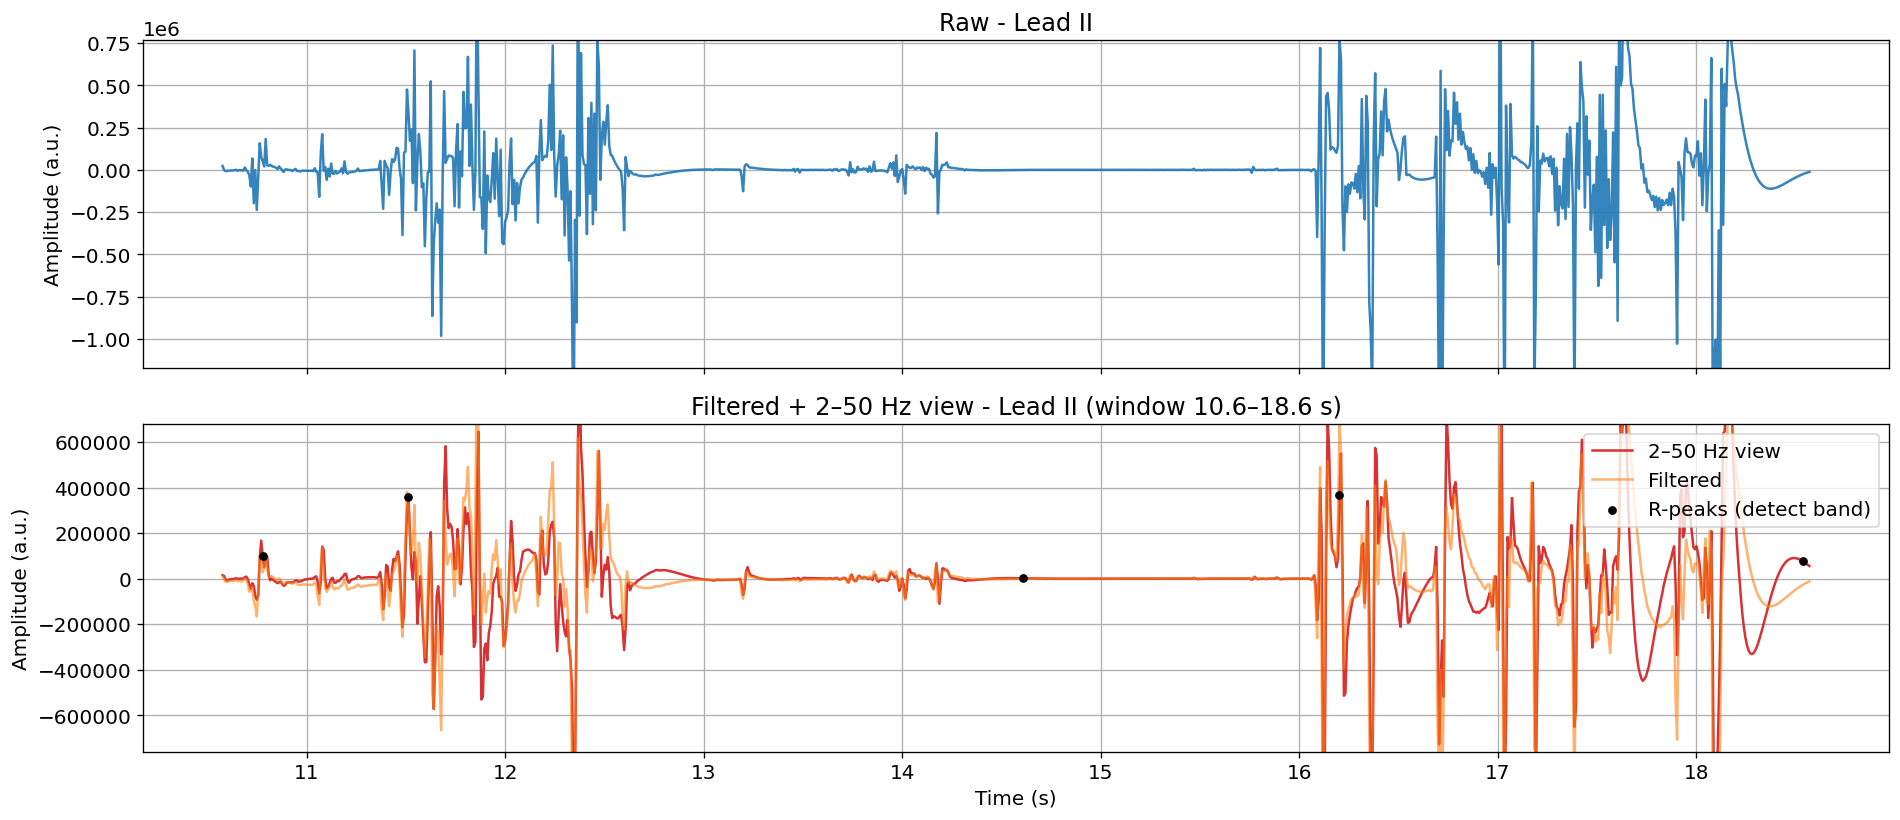

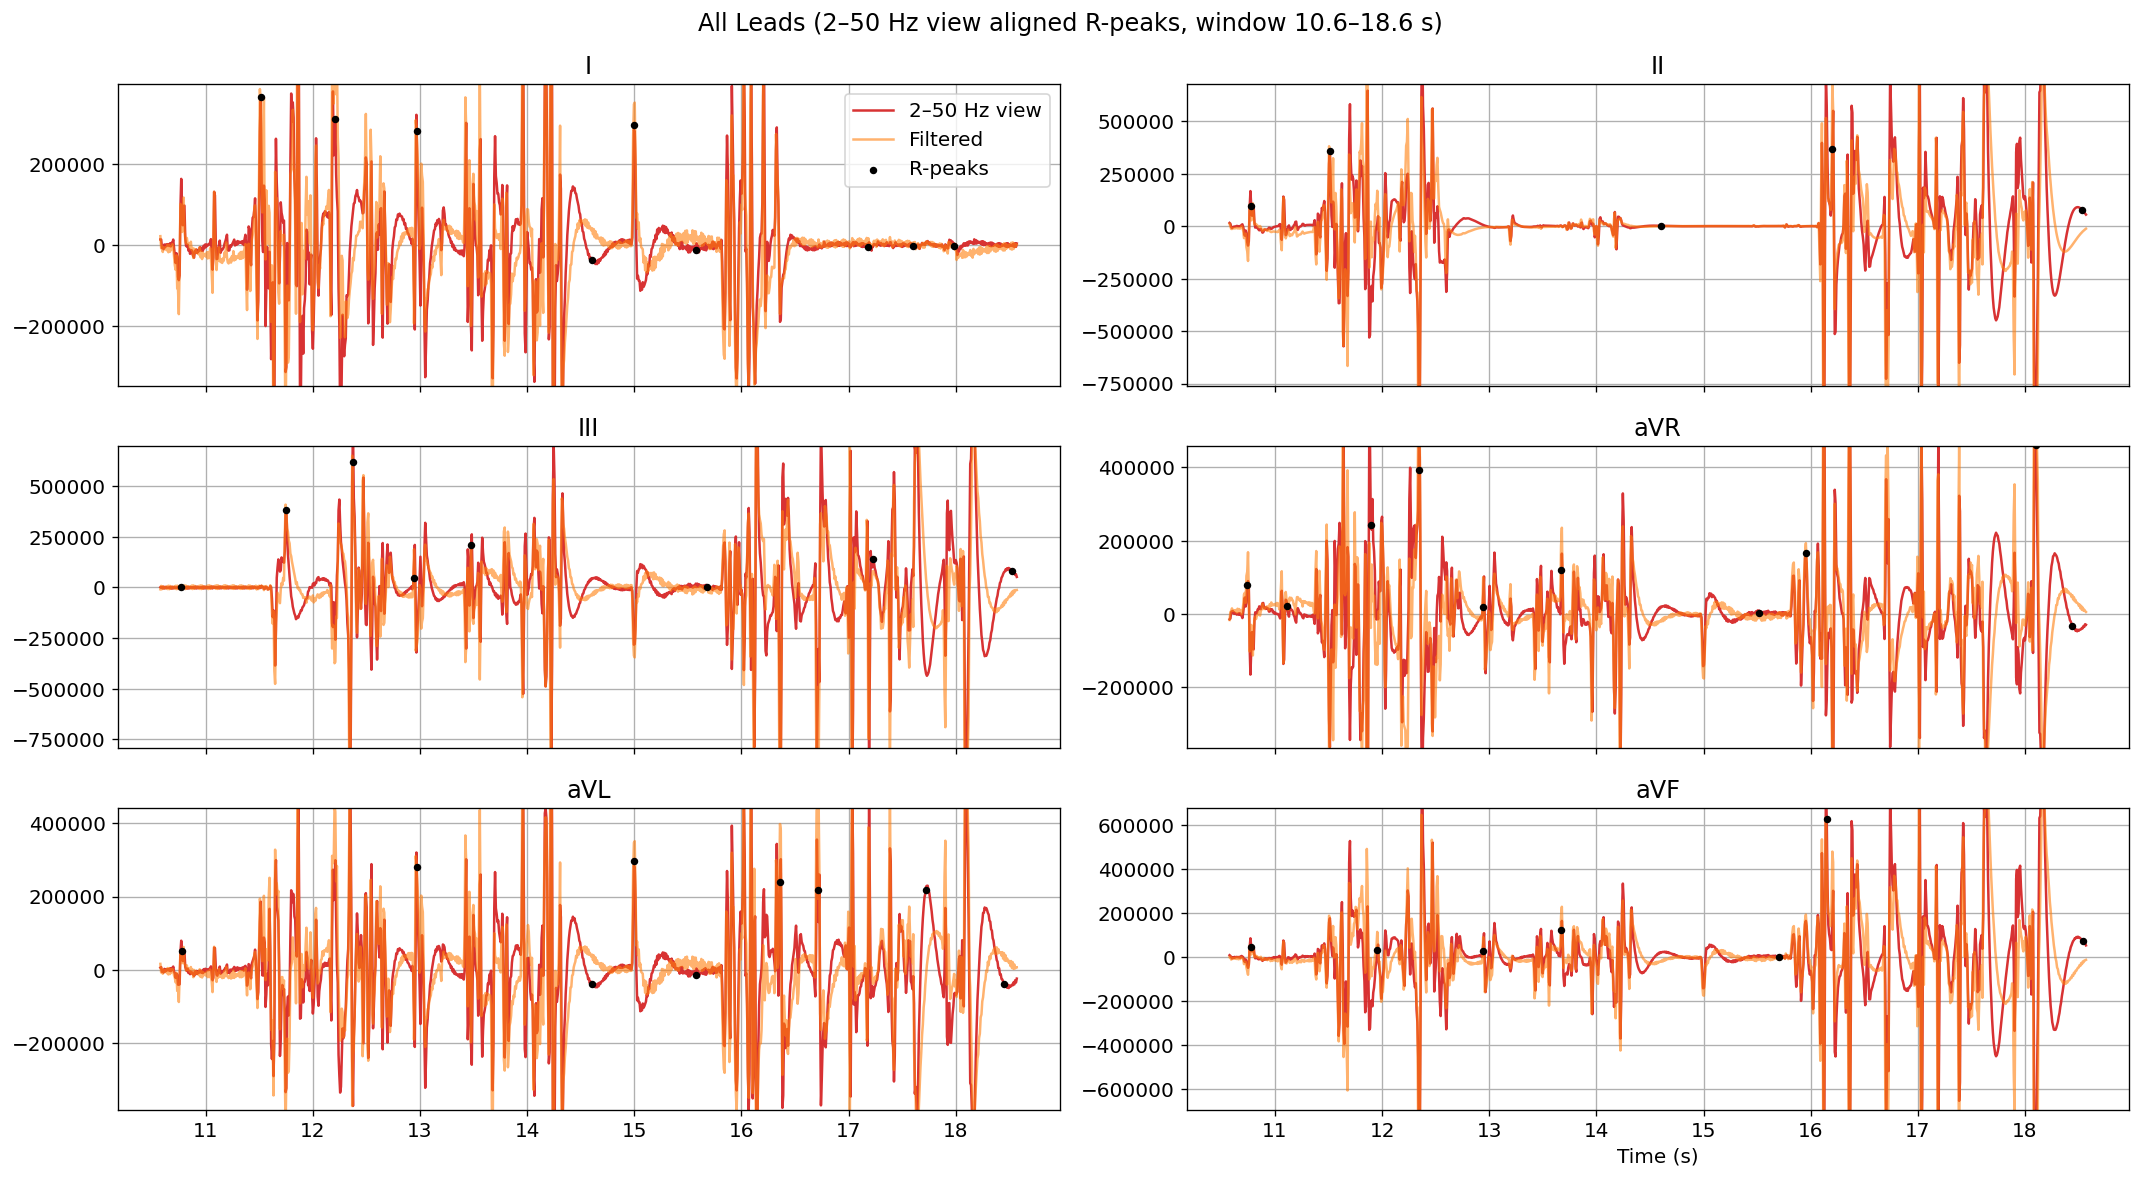

In [52]:
# Section 7: Visualize Raw vs Filtered Leads
if filt is not None:
    # Decide window: either user override, or auto best QRS window
    if cfg.auto_best_window and (globals().get('custom_start_sec') is None and globals().get('custom_view_dur') is None):
        start_auto, end_auto = find_best_window(filt, cfg.fs, dur=getattr(cfg, 'default_view_dur', 6.0))
        start_opt, dur_opt = start_auto, (end_auto - start_auto)
    else:
        # fallback to helper default window
        total_sec = len(filt) / cfg.fs
        s, e = choose_window(total_sec, globals().get('custom_start_sec'), globals().get('custom_view_dur'), default_dur=getattr(cfg, 'default_view_dur', 6.0))
        start_opt, dur_opt = s, e - s

    lead_idx = 1  # Lead II
    plot_lead_window(raw, filt, cfg.fs, lead_idx, start_opt, dur_opt)
    plot_all_leads_grid(raw, filt, cfg.fs, start_opt, dur_opt)

In [53]:
# Section 8: R-Peak Detection Helper
from scipy.signal import butter, sosfiltfilt, find_peaks, peak_widths

# Helper to choose detection input (Lead II vs PCA composite)
def get_detection_signal(filt_sig: np.ndarray) -> np.ndarray:
    if getattr(cfg, 'detect_use_pca_composite', False):
        try:
            return pca_composite(filt_sig)
        except Exception:
            return filt_sig[:, 1]
    else:
        return filt_sig[:, 1]

def detect_r_peaks(signal_1d: np.ndarray, fs: float,
                   min_hr: Optional[float] = None, max_hr: Optional[float] = None,
                   band_lo: Optional[float] = None, band_hi: Optional[float] = None,
                   order: Optional[int] = None,
                   prom_scale: Optional[float] = None,
                   min_rr_sec: Optional[float] = None,
                   width_lo_s: Optional[float] = None,
                   width_hi_s: Optional[float] = None,
                   rel_height: Optional[float] = None) -> np.ndarray:
    """
    Physiology-aware R-peak detection on a band-limited QRS view (default uses cfg.detect_*).
    Returns peak indices referenced to the original signal indexes.
    """
    if signal_1d is None or len(signal_1d) == 0:
        return np.array([], dtype=int)

    # Resolve defaults from cfg
    min_hr = cfg.detect_min_hr if min_hr is None else min_hr
    max_hr = cfg.detect_max_hr if max_hr is None else max_hr
    band_lo = cfg.detect_band_lo if band_lo is None else band_lo
    band_hi = cfg.detect_band_hi if band_hi is None else band_hi
    order = cfg.detect_order if order is None else order
    prom_scale = cfg.detect_prom_scale if prom_scale is None else prom_scale
    min_rr_sec = cfg.detect_min_rr_sec if min_rr_sec is None else min_rr_sec
    width_lo_s = cfg.detect_width_lo_s if width_lo_s is None else width_lo_s
    width_hi_s = cfg.detect_width_hi_s if width_hi_s is None else width_hi_s
    rel_height = cfg.detect_rel_height if rel_height is None else rel_height

    # Band-limit for QRS — detection band
    lo_w = band_lo / (fs / 2.0)
    hi_w = band_hi / (fs / 2.0)
    sos = butter(order, [lo_w, hi_w], btype='bandpass', output='sos')
    y = sosfiltfilt(sos, np.asarray(signal_1d))

    # Peak constraints
    min_distance = int(max(1, (60.0 / max_hr) * fs))
    refractory = int(max(min_distance, min_rr_sec * fs))

    # Robust IQR-based prominence
    q1, q3 = np.nanpercentile(y, [25, 75])
    iqr = max(q3 - q1, 1e-9)
    prom = float(prom_scale * iqr)

    peaks, props = find_peaks(y, distance=refractory, prominence=prom)

    if peaks.size == 0:
        return peaks

    # Width-based filtering
    widths_res = peak_widths(y, peaks, rel_height=rel_height)
    widths_samples = widths_res[0]
    widths_sec = widths_samples / fs
    keep = (widths_sec >= width_lo_s) & (widths_sec <= width_hi_s)
    peaks = peaks[keep]

    if peaks.size > 1 and refractory > 1:
        pruned = [int(peaks[0])]
        for pk in peaks[1:]:
            if pk - pruned[-1] >= refractory:
                pruned.append(int(pk))
        peaks = np.array(pruned, dtype=int)

    return peaks

In [54]:
# Section 9: Batch Processing All TXT Files

def summarize_signal(arr: np.ndarray) -> Dict[str, float]:
    nan_ratio = float(np.isnan(arr).mean())
    return {
        'samples': int(arr.shape[0]),
        'nan_ratio': nan_ratio,
        'std_mean': float(np.nanmean(np.nanstd(arr, axis=0)))
    }

records = []
for p in tqdm(list_txt_files(cfg.input_dir)):
    try:
        raw_i = load_ecg_txt(p)
        filt_i = process_ecg(raw_i, cfg.fs, cfg)
        # Choose detection input
        det_sig = get_detection_signal(filt_i)
        peaks_i = detect_r_peaks(det_sig, cfg.fs)
        rr_i = np.diff(peaks_i) / cfg.fs if len(peaks_i) > 1 else np.array([])
        hr_i = 60.0 / rr_i if rr_i.size else np.array([])

        # Save filtered CSV
        out_csv = cfg.output_dir / 'signals' / (p.stem + '_filtered.csv')
        df_out = pd.DataFrame(filt_i, columns=LEADS)
        df_out.to_csv(out_csv, index=False)

        rec = {
            'file': p.name,
            'duration_sec': float(len(filt_i) / cfg.fs),
            'beats': int(len(peaks_i)),
            'mean_hr_bpm': float(hr_i.mean()) if hr_i.size else np.nan,
            'median_hr_bpm': float(np.median(hr_i)) if hr_i.size else np.nan,
            **summarize_signal(raw_i),
        }
        records.append(rec)
    except Exception as e:
        records.append({'file': p.name, 'error': str(e)})

metrics_df = pd.DataFrame(records)
print('Batch processed files:', len(metrics_df))
metrics_df.head()

  0%|          | 0/12 [00:00<?, ?it/s]

Batch processed files: 12


,file,duration_sec,beats,mean_hr_bpm,median_hr_bpm,samples,nan_ratio,std_mean
0,seungyeon_1017_3min.txt,192.790262,197,88.471630,82.365583,51475,0.0,191245.977621
1,sgTest_20191207_205933.txt,245.449438,228,69.914805,59.114391,65535,0.0,6263.087818
2,sgTest_20191211_195304.txt,35.711610,43,98.428468,95.441682,9535,0.0,335466.170354
3,sgTest_20191211_200328.txt,66.498127,88,106.910486,113.617021,17755,0.0,357339.037949
4,sgTest_20191211_201510.txt,5.749064,8,88.145556,99.503106,1535,0.0,261399.502282


In [55]:
# Quick controls (optional): override default start/duration and display sampling here
# Feel free to set these and re-run Cells 5, 7, 7b, and 8.
custom_start_sec = None  # e.g., 2.5
custom_view_dur = None   # e.g., 8.0 (now wider by default)
custom_display_fs = None # e.g., 80.0 (Hz)

# Apply optional custom display rate override
if custom_display_fs is not None:
    cfg.display_target_fs = float(custom_display_fs)

# Toggle denoise stages here
cfg.heartpy_enable = False  # True to enable HeartPy
cfg.emd_enable = False      # True to enable EMD/EEMD
cfg.emd_mode = 'emd'        # 'emd' or 'eemd'
cfg.adaptive_notch_enable = False  # True to auto-detect mains and notch

### 더 넓게 보는 방법 요약
- 전역 그림 크기를 크게 설정했습니다: 16x7, dpi 120
- 주요 Matplotlib 플롯과 위젯 뷰어의 figsize를 확대했습니다.
- 3x2 그리드도 18x10으로 확대했습니다.
- 더 길게 보고 싶으면 `cfg.default_view_dur`를 8~12로 늘려 보세요.

### HeartPy 노이즈 제거 옵션
- cfg.heartpy_enable = True 로 설정하면 HeartPy의 filter_signal을 각 리드에 적용합니다.
- 기본 cutoff는 0.05 (상대 주파수)이며 필요 시 cfg.heartpy_cutoff 값을 조정하세요.
- HeartPy 적용은 기존 필터 파이프라인(밴드패스/노치/베이스라인/햄펠/웨이블릿) 이후 마지막 단계로 수행됩니다.

### EMD/EEMD & Adaptive Notch 사용법
- EMD/EEMD: `cfg.emd_enable=True`, `cfg.emd_mode='emd'` 또는 `'eemd'`. 고주파 잡음 억제를 위해 첫 K개 IMF(`cfg.emd_remove_first_k`)를 제거하고 재구성합니다.
- Adaptive Notch: `cfg.adaptive_notch_enable=True` → 48~62 Hz 범위에서 전력선 주파수를 추정해 노치 필터를 자동 적용(+고조파).
- 설치: 설치 셀의 `PyEMD` 주석을 제거하고 실행하세요.

### Tip: 화면 확대 옵션
- 그림이 더 크게 보이도록 전역 figsize를 (16, 7)로 늘렸고, 주요 플롯의 figsize도 키웠습니다.
- 노트북 우측 상단의 확대(Zoom in) 또는 브라우저 110~125% 확대도 함께 활용해 보세요.
- 한 번에 더 길게 보고 싶으면 `cfg.default_view_dur`를 8~12초로 조정하세요.

# Section 12: Optional Interactive Explorer (requires ipywidgets)
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    files = list_txt_files(cfg.input_dir)
    file_options = [p.name for p in files]
    file_dd = widgets.Dropdown(options=file_options, description='File:')
    lead_dd = widgets.Dropdown(options=LEADS, description='Lead:')
    t_start = widgets.FloatSlider(value=0.0, min=0.0, max=10.0, step=0.5, description='Start (s)')
    t_dur = widgets.FloatSlider(value=6.0, min=1.0, max=15.0, step=0.5, description='Dur (s)')
    show_temp = widgets.Checkbox(value=False, description='Show Temperature')

    out = widgets.Output()

    def update_plot(*args):
        with out:
            clear_output(wait=True)
            if not files:
                print('No files found')
                return
            p = files[file_options.index(file_dd.value)]
            raw_i = load_ecg_txt(p)
            filt_i = process_ecg(raw_i, cfg.fs, cfg)
            li = LEADS.index(lead_dd.value)
            a, b = seconds_to_samples((t_start.value, t_start.value + t_dur.value), cfg.fs)
            a = max(0, min(a, len(raw_i)))
            b = max(0, min(b, len(raw_i)))
            if b - a < 2:
                print('Select a longer range')
                return

            # Build time vector for the window (before resample)
            t_seg = np.arange(a, b) / cfg.fs

            # Display band view per config
            lo_w = cfg.display_band_lo/(cfg.fs/2); hi_w = cfg.display_band_hi/(cfg.fs/2)
            bp = butter(2, [lo_w, hi_w], btype='bandpass', output='sos')
            disp_full = sosfilt(bp, filt_i[:, li])

            # Anti-aliased resampling for clarity
            try:
                from fractions import Fraction
                from scipy.signal import resample_poly
                target = float(getattr(cfg, 'display_target_fs', 120.0))
                ratio = Fraction(target, cfg.fs).limit_denominator(20)
                up, down = ratio.numerator, ratio.denominator
                # Resample signals in the selected window
                y_raw = resample_poly(raw_i[a:b, li], up, down)
                y_disp = resample_poly(disp_full[a:b], up, down)
                y_flt = resample_poly(filt_i[a:b, li], up, down)
                t = np.linspace(t_seg[0], t_seg[-1], len(y_raw), endpoint=True)
            except Exception:
                # Fallback to simple decimation
                step = compute_decimation(cfg.fs, getattr(cfg, 'display_target_fs', 120.0))
                t = t_seg[::step]
                y_raw = raw_i[a:b:step, li]
                y_disp = disp_full[a:b:step]
                y_flt = filt_i[a:b:step, li]

            # Percentile-based y-limits for better contrast
            r_lo, r_hi = np.nanpercentile(y_raw, [1, 99])
            f_lo, f_hi = np.nanpercentile(y_disp, [1, 99])

            # Layout rows: raw, filtered+view, optional temperature
            rows = 3 if (show_temp.value and 'last_temp' in globals()) else 2
            fig, axes = plt.subplots(rows, 1, figsize=(16, 8 if rows==2 else 10), sharex=True)
            if rows == 2:
                axes0, axes1 = axes[0], axes[1]
            else:
                axes0, axes1, ax_temp = axes[0], axes[1], axes[2]

            # Raw
            axes0.plot(t, y_raw, label='Raw', alpha=0.9, color='C0', lw=0.9)
            axes0.set_title(f'{p.name} - Raw {LEADS[li]} (main: {getattr(cfg, "device_fl", 2.0):.1f}-{getattr(cfg, "device_fh", 50.0):.0f} Hz Butterworth, order {getattr(cfg, "device_order", 2)})')
            axes0.set_ylabel('Amp (a.u.)')
            axes0.set_ylim(r_lo, r_hi)

            # Bottom: display band view + filtered
            axes1.plot(t, y_disp, label=f'{cfg.display_band_lo:.0f}–{cfg.display_band_hi:.0f} Hz view', alpha=0.95, color='C3')
            axes1.plot(t, y_flt, label='Filtered', alpha=0.6, color='C1')

            # R-peaks on detection band
            if 'detect_r_peaks' in globals():
                det_sig = get_detection_signal(filt_i) if getattr(cfg, 'detect_use_pca_composite', False) else filt_i[:, li]
                peaks = detect_r_peaks(
                    det_sig, cfg.fs,
                    band_lo=getattr(cfg, 'detect_band_lo', 5.0),
                    band_hi=getattr(cfg, 'detect_band_hi', 20.0),
                    order=getattr(cfg, 'detect_order', 2),
                )
                mask = (peaks >= a) & (peaks < b)
                peaks_w = peaks[mask]
                if peaks_w.size:
                    # align with display-band filtered samples; index map via time
                    tp = peaks_w / cfg.fs
                    axes1.scatter(tp, disp_full[peaks_w], c='k', s=16, label='R-peaks', zorder=3)

            axes1.set_title(f'{p.name} - Filtered {LEADS[li]} ({cfg.display_band_lo:.0f}–{cfg.display_band_hi:.0f} Hz view)')
            axes1.set_xlabel('Time (s)'); axes1.set_ylabel('Amp (a.u.)')
            axes1.set_ylim(f_lo, f_hi)
            axes1.legend(loc='upper right')

            # Temperature subplot if requested
            if rows == 3:
                temp = globals().get('last_temp', None)
                if temp is not None and len(temp) >= b:
                    # Temperature resample to match t length
                    try:
                        from scipy.signal import resample
                        temp_seg = temp[a:b]
                        temp_r = resample(temp_seg, len(t))
                        ax_temp.plot(t, temp_r, color='C2')
                    except Exception:
                        ax_temp.plot(t_seg, temp[a:b], color='C2')
                    ax_temp.set_ylabel('Temp (°C)')
                    ax_temp.set_title('Temperature')

            plt.tight_layout(); plt.show()

    for w in [file_dd, lead_dd, t_start, t_dur, show_temp]:
        w.observe(update_plot, names='value')

    display(widgets.VBox([widgets.HBox([file_dd, lead_dd]), widgets.HBox([t_start, t_dur, show_temp]), out]))
    update_plot()
except Exception as e:
    print('ipywidgets not available or failed to load:', e)

In [56]:
# Section 9: Batch Processing All TXT Files

def summarize_signal(arr: np.ndarray) -> Dict[str, float]:
    nan_ratio = float(np.isnan(arr).mean())
    return {
        'samples': int(arr.shape[0]),
        'nan_ratio': nan_ratio,
        'std_mean': float(np.nanmean(np.nanstd(arr, axis=0)))
    }

records = []
for p in tqdm(list_txt_files(cfg.input_dir)):
    try:
        raw_i = load_ecg_txt(p)
        filt_i = process_ecg(raw_i, cfg.fs, cfg)
        det_sig = get_detection_signal(filt_i)
        peaks_i = detect_r_peaks(det_sig, cfg.fs)
        rr_i = np.diff(peaks_i) / cfg.fs if len(peaks_i) > 1 else np.array([])
        hr_i = 60.0 / rr_i if rr_i.size else np.array([])

        # Save filtered CSV
        out_csv = cfg.output_dir / 'signals' / (p.stem + '_filtered.csv')
        df_out = pd.DataFrame(filt_i, columns=LEADS)
        df_out.to_csv(out_csv, index=False)

        rec = {
            'file': p.name,
            'duration_sec': float(len(filt_i) / cfg.fs),
            'beats': int(len(peaks_i)),
            'mean_hr_bpm': float(hr_i.mean()) if hr_i.size else np.nan,
            'median_hr_bpm': float(np.median(hr_i)) if hr_i.size else np.nan,
            'used_heartpy': bool(getattr(cfg, 'heartpy_enable', False)),
            **summarize_signal(raw_i),
        }
        records.append(rec)
    except Exception as e:
        records.append({'file': p.name, 'error': str(e)})

metrics_df = pd.DataFrame(records)
metrics_df

  0%|          | 0/12 [00:00<?, ?it/s]

,file,duration_sec,beats,mean_hr_bpm,median_hr_bpm,used_heartpy,samples,nan_ratio,std_mean
0,seungyeon_1017_3min.txt,192.790262,197,88.471630,82.365583,False,51475,0.0,191245.977621
1,sgTest_20191207_205933.txt,245.449438,228,69.914805,59.114391,False,65535,0.0,6263.087818
2,sgTest_20191211_195304.txt,35.711610,43,98.428468,95.441682,False,9535,0.0,335466.170354
3,sgTest_20191211_200328.txt,66.498127,88,106.910486,113.617021,False,17755,0.0,357339.037949
4,sgTest_20191211_201510.txt,5.749064,8,88.145556,99.503106,False,1535,0.0,261399.502282
5,sgTest_20191211_201736.txt,21.104869,13,80.319992,55.809889,False,5635,0.0,581177.230928
6,sgTest_20191211_202004.txt,9.644195,16,107.769368,97.682927,False,2575,0.0,171582.845848
7,승연_움ㅈ3ㅣㄱ임.txt,109.194757,143,108.180062,116.086957,False,29155,0.0,44300.800469
8,태규비정상.txt,92.340824,122,102.252445,116.086957,False,24655,0.0,49713.869637
9,태규정상.txt,204.026217,289,105.256976,116.086957,False,54475,0.0,37432.508849


In [57]:
# Section 10: Save Processed Signals and Metrics
# Save metrics and run configuration
metrics_csv = cfg.output_dir / 'metrics.csv'
metrics_df.to_csv(metrics_csv, index=False)

run_cfg = {
    'fs': cfg.fs,
    'hp_cut': cfg.hp_cut,
    'hp_order': cfg.hp_order,
    'notch_enable': cfg.notch_enable,
    'notch_freq': cfg.notch_freq,
    'notch_q': cfg.notch_q,
    'input_dir': str(cfg.input_dir),
    'output_dir': str(cfg.output_dir),
}
with (cfg.output_dir / 'config.json').open('w', encoding='utf-8') as f:
    json.dump(run_cfg, f, ensure_ascii=False, indent=2)

print('Saved:', metrics_csv)
print('Saved:', cfg.output_dir / 'config.json')

Saved: out/metrics.csv
Saved: out/config.json


In [58]:
# Section 11: Basic Sanity Tests (response, attenuation)

def test_dc_attenuation(fs: float):
    x = np.ones((int(3*fs), 1)) * 5.0
    y = sosfiltfilt(main_sos, x, axis=0)
    return float(np.abs(y.mean()))

m = test_dc_attenuation(cfg.fs)
print('DC attenuation mean abs (should be ~0):', m)

# Frequency response check (for device-like bandpass): |H(0.2 Hz)| << |H(5 Hz)|
w, h = sosfreqz(main_sos, worN=4096, fs=cfg.fs)
mag = np.abs(h)
mag_0p2 = float(np.interp(0.2, w, mag))
mag_5 = float(np.interp(5.0, w, mag))
print('|H(0.2 Hz)| vs |H(5 Hz)|:', mag_0p2, mag_5)
assert mag_0p2 < 0.2 * mag_5 + 1e-6, 'Main filter separation check failed'

# Shape equality
if 'raw' in globals() and filt is not None:
    assert raw.shape == filt.shape, 'Shape mismatch after filtering'
    print('Shape equality OK')

DC attenuation mean abs (should be ~0): 6.657946646262333e-28
|H(0.2 Hz)| vs |H(5 Hz)|: 0.009338780646844425 0.9946200015222437
Shape equality OK


In [74]:
# Section 12: Optional Interactive Explorer (requires ipywidgets)
try:
    import numpy as np
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    # Ensure signal imports are always available even on a fresh kernel
    from scipy.signal import butter, sosfiltfilt

    files = list_txt_files(cfg.input_dir)
    file_options = [p.name for p in files]
    file_dd = widgets.Dropdown(options=file_options, description='File:')
    lead_dd = widgets.Dropdown(options=LEADS, description='Lead:')
    # Use a dynamic range slider for [start, end] in seconds
    t_range = widgets.FloatRangeSlider(value=[0.0, 6.0], min=0.0, max=10.0, step=0.1,
                                       description='Range (s)', continuous_update=False)
    # Toggle artifact-suppressed display and detector method
    show_artf_supp = widgets.Checkbox(value=True, description='Artifact-suppressed view')
    show_artf_mask = widgets.Checkbox(value=True, description='Shade artifacts')
    method_dd = widgets.Dropdown(options=['robust','swt','swt_lib'], value='robust', description='Detector')

    out = widgets.Output()

    def update_plot(*args):
        with out:
            clear_output(wait=True)
            if not files:
                print('No files found')
                return
            p = files[file_options.index(file_dd.value)]
            raw_i = load_ecg_txt(p)
            filt_i = process_ecg(raw_i, cfg.fs, cfg)
            li = LEADS.index(lead_dd.value)

            # Dynamically adapt slider max to file duration
            total_sec = len(raw_i) / cfg.fs
            if abs(t_range.max - total_sec) > 1e-6:
                t_range.max = float(total_sec)
                # clamp existing value into new bounds and ensure non-zero width
                s0, s1 = t_range.value
                s0 = max(0.0, min(s0, total_sec))
                s1 = max(s0 + 0.1, min(s1, total_sec))
                t_range.value = (s0, s1)

            s0, s1 = t_range.value
            a, b = seconds_to_samples((s0, s1), cfg.fs)
            a = max(0, min(a, len(raw_i)))
            b = max(0, min(b, len(raw_i)))
            # Ensure a valid window and a valid step
            step = max(1, int(compute_decimation(cfg.fs, getattr(cfg, 'display_target_fs', 120.0))))
            if b <= a:
                # expand to at least 0.5s when slider is too tight
                b = min(len(raw_i), a + max(1, int(round(0.5 * cfg.fs))))
                if b <= a:
                    print('Selected window too small; please widen the Range (s).')
                    return
            # Build explicit indices once to keep consistent slicing
            idxs = np.arange(a, b, step)
            if idxs.size < 2:
                # try relaxing step
                idxs = np.arange(a, b)
            if idxs.size < 2:
                print('Selected window contains insufficient samples to display.')
                return
            t = idxs / cfg.fs

            # Artifact detection (lead II reference) once per window for speed
            art_mask = None
            if getattr(cfg, 'artifact_enable', False):
                art_mask = detect_artifacts(raw_i, cfg.fs, cfg)

            # Build artifact-suppressed display (optional): inpaint only inside window for visual clarity
            disp_band = None
            disp_band_supp = None
            lo_w = cfg.display_band_lo/(cfg.fs/2); hi_w = cfg.display_band_hi/(cfg.fs/2)
            # Use zero-phase display to avoid phase lag between peaks & trace
            bp = butter(2, [lo_w, hi_w], btype='bandpass', output='sos')
            disp_full = sosfiltfilt(bp, filt_i[:, li])
            disp_local_win = None
            if show_artf_supp.value and art_mask is not None:
                # local copy for display only
                disp_local = disp_full.copy()
                # Inpaint artifacts within window
                if art_mask.any():
                    disp_local = disp_local if disp_local.ndim == 1 else disp_local.ravel()
                    disp_local = np.asarray(disp_local)
                    disp_local_win = _linear_inpaint(disp_local.copy(), art_mask)
                    disp_band_supp = disp_local_win[idxs]
                else:
                    disp_band_supp = disp_full[idxs]
            disp_band = disp_full[idxs]

            # Separate subplots: Raw (top), Filtered (bottom)
            fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
            raw_seg = raw_i[idxs, li]
            axes[0].plot(t, raw_seg, label='Raw', alpha=0.85, color='C0')
            axes[0].set_title(f'{p.name} - Raw {LEADS[li]}')
            axes[0].set_ylabel('Amp (a.u.)')

            # Percentile-based y-limits for stability (wider range with padding)
            if raw_seg.size > 10:
                rl, rh = np.nanpercentile(raw_seg, [1, 99])
                pad = 0.40 * (rh - rl) if np.isfinite(rh - rl) else 0.0
                if pad == 0:
                    pad = max(1e-3, 0.08 * (abs(rh) + abs(rl) + 1e-6))
                axes[0].set_ylim(rl - pad, rh + pad)

            # Shade artifacts
            if show_artf_mask.value and art_mask is not None and art_mask.any():
                am = art_mask[a:b]
                if am.any():
                    tt = np.arange(a, b) / cfg.fs
                    on = False; sstart = 0
                    for i_idx, flag in enumerate(am):
                        if flag and not on:
                            on = True; sstart = i_idx
                        if on and (not flag or i_idx == len(am)-1):
                            e = i_idx if not flag else i_idx+1
                            axes[0].axvspan(tt[sstart], tt[e-1], color='red', alpha=0.08)
                            axes[1].axvspan(tt[sstart], tt[e-1], color='red', alpha=0.08)
                            on = False

            # Filtered traces
            filt_seg = filt_i[idxs, li]
            axes[1].plot(t, filt_seg, label='Filtered', alpha=0.55, color='C1')
            axes[1].plot(t, disp_band, label=f'Display {cfg.display_band_lo:.0f}–{cfg.display_band_hi:.0f} Hz', alpha=0.9, color='C3')
            if disp_band_supp is not None:
                axes[1].plot(t, disp_band_supp, label='Artifact-suppressed', alpha=0.9, color='tabgreen')

            # R-peaks: choose method
            peaks = np.array([], dtype=int)
            used_backend = None
            if method_dd.value == 'swt' and 'swt_detect_r_peaks' in globals():
                det_sig = filt_i[:, li]
                if art_mask is not None and art_mask.any():
                    det_sig = _linear_inpaint(det_sig.copy(), art_mask)
                peaks = swt_detect_r_peaks(
                    det_sig, cfg.fs,
                    wavelet=getattr(cfg, 'swt_wavelet', 'coif2'),
                    max_level=getattr(cfg, 'swt_max_level', 6),
                    use_levels=getattr(cfg, 'swt_use_levels', None),
                    fixed_thr=getattr(cfg, 'swt_fixed_thr', 0.5),
                    integrate_ms=getattr(cfg, 'swt_integrate_ms', 120),
                    k=getattr(cfg, 'swt_k', 3.0),
                    min_rr_ms=getattr(cfg, 'swt_min_rr_ms', 250),
                    art_mask=art_mask,
                    refine_bp=(getattr(cfg, 'detect_band_lo', 5.0), getattr(cfg, 'detect_band_hi', 20.0)),
                    refine_win_ms=getattr(cfg, 'swt_refine_win_ms', 80)
                )
                if peaks.size:
                    used_backend = 'swt'
            elif method_dd.value == 'swt_lib':
                try:
                    from ecgdetectors import Detectors
                    det = Detectors(cfg.fs)
                    raw_det = raw_i[:, li].copy()
                    if art_mask is not None and art_mask.any():
                        raw_det = _linear_inpaint(raw_det, art_mask)
                    peaks = np.array(det.swt_detector(raw_det), dtype=int)
                    if peaks.size:
                        used_backend = 'swt_lib'
                except Exception as _e:
                    axes[1].text(0.02, 0.93, 'Install py-ecg-detectors to use swt_lib', transform=axes[1].transAxes, fontsize=9, color='gray')
            if (peaks.size == 0) and ('detect_r_peaks_robust' in globals()):
                # Fallback to robust backend so R-peaks remain visible
                det_sig = filt_i[:, li]
                if art_mask is not None and art_mask.any():
                    det_sig = _linear_inpaint(det_sig.copy(), art_mask)
                peaks = detect_r_peaks_robust(
                    det_sig, cfg.fs,
                    band_lo=getattr(cfg, 'detect_band_lo', 5.0),
                    band_hi=getattr(cfg, 'detect_band_hi', 20.0),
                    order=getattr(cfg, 'detect_order', 2),
                    integrate_ms=getattr(cfg, 'detect_integrate_ms', 150),
                    k=getattr(cfg, 'detect_k', 3.0),
                    min_rr_ms=getattr(cfg, 'detect_min_rr_ms', 250),
                    art_mask=art_mask
                )
                used_backend = 'robust'

            # Plot peaks (only those within the current window)
            if peaks.size:
                y_series = disp_local_win if (disp_band_supp is not None and disp_local_win is not None) else disp_full
                in_win = (peaks >= a) & (peaks < b)
                peaks_w = peaks[in_win]
                if peaks_w.size:
                    axes[1].scatter(peaks_w / cfg.fs, y_series[peaks_w], c='k', s=16, label='R-peaks', zorder=3)
                    if used_backend == 'robust' and method_dd.value in ('swt','swt_lib'):
                        axes[1].text(0.02, 0.86, 'Fallback to robust detector', transform=axes[1].transAxes, fontsize=9, color='gray')
                else:
                    axes[1].text(0.02, 0.9, 'No peaks in this window', transform=axes[1].transAxes, fontsize=9, color='gray')
            else:
                axes[1].text(0.02, 0.9, 'No peaks detected', transform=axes[1].transAxes, fontsize=9, color='gray')

            # Y-limit stabilization for filtered view (wider range with padding)
            combined = disp_band_supp if (disp_band_supp is not None) else disp_band
            if combined.size > 10:
                fl, fh = np.nanpercentile(combined, [1, 99])
                pad = 0.40 * (fh - fl) if np.isfinite(fh - fl) else 0.0
                if pad == 0:
                    pad = max(1e-3, 0.08 * (abs(fh) + abs(fl) + 1e-6))
                axes[1].set_ylim(fl - pad, fh + pad)

            axes[1].set_title(f'{p.name} - Filtered {LEADS[li]} (Artifacts handled)')
            axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Amp (a.u.)')
            axes[1].legend(loc='upper right', ncol=2, fontsize=9)

            plt.tight_layout(); plt.show()

    for w in [file_dd, lead_dd, t_range, show_artf_supp, show_artf_mask, method_dd]:
        w.observe(update_plot, names='value')

    display(widgets.VBox([widgets.HBox([file_dd, lead_dd, method_dd]), widgets.HBox([t_range]), widgets.HBox([show_artf_supp, show_artf_mask]), out]))
    update_plot()
except Exception as e:
    print('ipywidgets not available or failed to load:', e)

In [60]:
# Section 7b: Interactive Plotly viewer (single lead)
try:
    import plotly.graph_objects as go
    def plotly_lead(raw_sig: np.ndarray, filt_sig: np.ndarray, fs: float, lead_idx: int = 1, show_best_window: bool = True):
        n = len(filt_sig)
        t = np.arange(n) / fs
        # display bandpass for clarity
        lo_w = getattr(cfg, 'display_band_lo', 5.0)/(fs/2); hi_w = getattr(cfg, 'display_band_hi', 20.0)/(fs/2)
        bp = butter(2, [lo_w, hi_w], btype='bandpass', output='sos')
        disp = sosfilt(bp, filt_sig[:, lead_idx])

        fig = go.Figure()
        # Optional downsampling for rendering performance
        step = compute_decimation(fs, getattr(cfg, 'display_target_fs', 120.0))
        fig.add_trace(go.Scattergl(x=t[::step], y=filt_sig[::step, lead_idx], name='Filtered', mode='lines'))
        fig.add_trace(go.Scattergl(x=t[::step], y=disp[::step], name=f'{cfg.display_band_lo:.0f}–{cfg.display_band_hi:.0f} Hz view', mode='lines'))

        # Optional best-window markers
        if show_best_window and getattr(cfg, 'auto_best_window', True):
            s, e = find_best_window(filt_sig, fs, dur=getattr(cfg, 'default_view_dur', 8.0), lo=getattr(cfg, 'display_band_lo', 5.0), hi=getattr(cfg, 'display_band_hi', 20.0))
            fig.add_vrect(x0=s, x1=e, fillcolor="LightGreen", opacity=0.25, line_width=0, annotation_text="best", annotation_position="top left")

        fig.update_layout(title=f'Lead {LEADS[lead_idx]} (interactive)', xaxis_title='Time (s)', yaxis_title='Amplitude',
                          xaxis=dict(rangeslider=dict(visible=True)), hovermode='x unified', width=1200, height=500)
        fig.show()

    if filt is not None:
        plotly_lead(raw, filt, cfg.fs, 1)
except Exception as e:
    print('Plotly not available or failed to render:', e)

## R-peak interval basics and tuning (설명)

- 정상 심박수에서 RR 간격은 대략 0.6–1.2초(50–100 bpm)이며, 매우 빠른 경우라도 0.33초(≈180 bpm)보다 짧아지기는 어렵습니다.

- 본 노트북의 검출기는 다음의 객관적 절차를 따릅니다:

  1) QRS 대역(기본 8–20 Hz) 대역통과 후

  2) 피크 찾기: 최대 심박수에 따른 최소 간격과 생리적 불응기(min_rr_sec≈0.33 s)를 적용

  3) IQR 기반 prominence 임계(prom_scale×IQR)

  4) 폭 기반 필터링: QRS 폭이 40–200 ms 범위만 유지

- 튜닝 노브(cfg):

  - detect_min_hr / detect_max_hr: 허용 심박 범위

  - detect_band_lo / detect_band_hi: 검출용 대역

  - detect_min_rr_sec: 불응기(최소 RR)

  - detect_prom_scale: prominence 민감도(크면 덜 검출)

  - detect_width_lo_s / detect_width_hi_s: QRS 폭 범위

- 만약 과검출로 보이면:

  1) detect_prom_scale 값을 0.6→0.8로 높이거나

  2) detect_min_rr_sec 를 0.33→0.40 s 로 늘리거나

  3) detect_band_lo 를 8→10 Hz 로 올려 T-wave 영향 줄이기


## Noise-reduction options added (요약)

- Notch: base 50/60 Hz + optional harmonics (cfg.notch_enable, notch_q, notch_harmonics)

- Baseline detrend: median(~200 ms) + moving average(~600 ms) (cfg.baseline_mode='median_ma')

- Hampel spike suppressor: short window(≈120 ms), k≈3 (cfg.hampel_enable)

- Wavelet denoise: db4, level 5 soft-threshold (cfg.wavelet_enable; requires pywt)

- Display/detect bands are configurable: cfg.display_band_lo/hi, cfg.detect_band_lo/hi

- Optional multi-lead PCA composite for detection: cfg.detect_use_pca_composite=True

안전한 권장 순서: HP → (Notch) → (Baseline) → (Hampel) → (Wavelet). 시각화는 display band, 검출은 detect band를 사용합니다.

In [61]:
# Section: SQI computation and export
if 'filt' in globals() and filt is not None and getattr(cfg, 'sqi_enable', False):
    sqi_t, sqi_v = compute_sqi_series(filt, cfg.fs, cfg)
    if sqi_t.size:
        sqi_df = pd.DataFrame({'time_sec': sqi_t, 'sqi': sqi_v})
        out_sqi = cfg.output_dir / 'signals' / 'sqi.csv'
        sqi_df.to_csv(out_sqi, index=False)
        display(sqi_df.head())
        print('Saved SQI:', out_sqi)
    else:
        print('SQI series empty (check window/step settings).')
else:
    print('SQI disabled or filtered signal not available.')

,time_sec,sqi
0,2.0,0.613547
1,4.0,0.580210
2,6.0,0.556220
3,8.0,0.646657
4,10.0,0.560891


Saved SQI: out/signals/sqi.csv


In [62]:
# Re-add SQI timeline plotting helper (missing)
import matplotlib.pyplot as plt

def plot_sqi_artifact_timeline(raw_sig: np.ndarray, filt_sig: np.ndarray, fs: float, cfg: Config,
                                sqi_t: np.ndarray, sqi_v: np.ndarray, art_mask: np.ndarray | None,
                                peaks: np.ndarray | None = None, min_sqi: float = 0.4):
    dur = len(raw_sig)/fs
    fig, axes = plt.subplots(3,1, figsize=(16,8), sharex=True)
    t = np.arange(len(raw_sig))/fs
    lead = 1 if raw_sig.shape[1] > 1 else 0
    axes[0].plot(t, raw_sig[:, lead], lw=0.6, color='C0')
    axes[0].set_ylabel('Raw')
    if art_mask is not None and art_mask.any():
        on=False; s0=0
        for i,flag in enumerate(art_mask):
            if flag and not on:
                on=True; s0=i
            if on and (not flag or i==len(art_mask)-1):
                e=i if not flag else i+1
                axes[0].axvspan(s0/fs, (e-1)/fs, color='red', alpha=0.05)
                on=False
    axes[0].set_title('Raw with artifact shading')
    axes[1].plot(sqi_t, sqi_v, marker='o', ms=3, lw=1, color='C2')
    axes[1].axhline(min_sqi, color='r', ls='--', alpha=0.5, label='SQI threshold')
    axes[1].set_ylabel('SQI'); axes[1].set_ylim(-0.05,1.05); axes[1].legend()
    if art_mask is not None and art_mask.size:
        art_t, art_r = compute_artifact_ratio_series(art_mask, fs, getattr(cfg,'adapt_window_sec',8.0), getattr(cfg,'adapt_step_sec',2.0))
    else:
        art_t, art_r = np.array([]), np.array([])
    if art_t.size:
        axes[2].plot(art_t, art_r, marker='.', lw=1, color='C1')
        axes[2].set_ylabel('Artifact ratio')
    else:
        axes[2].text(0.5,0.5,'No artifact ratio data', ha='center', va='center')
    axes[2].set_xlabel('Time (s)')
    if peaks is not None and peaks.size:
        axes[0].scatter(peaks/fs, raw_sig[peaks, lead], s=12, c='k', label='R-peaks cleaned', zorder=3)
        axes[0].legend(loc='upper right')
    plt.tight_layout(); plt.show()

print('Timeline helper re-added.')

Timeline helper re-added.


In [63]:
# Fallback compute_sqi_series if not in globals (cell ordering safety)
if 'compute_sqi_series' not in globals():
    def compute_sqi_series(x: np.ndarray, fs: float, cfg: Config) -> tuple[np.ndarray, np.ndarray]:
        return np.array([]), np.array([])
    print('compute_sqi_series fallback (empty) injected.')

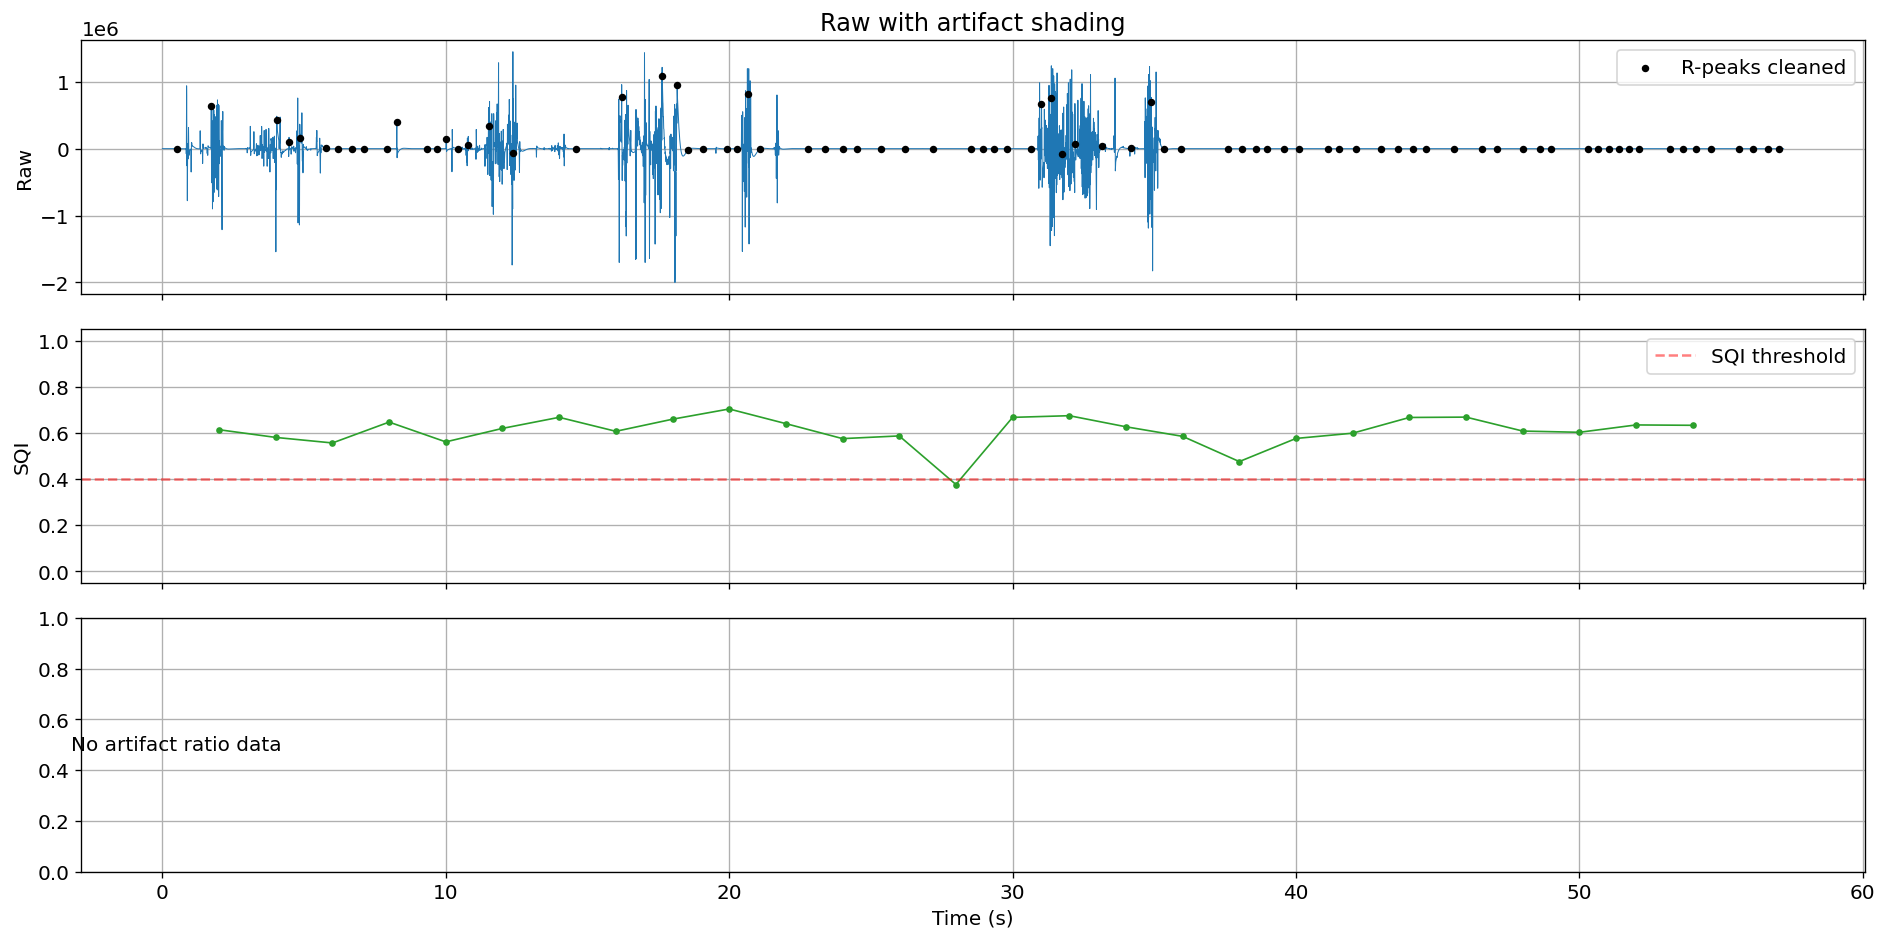

Peaks (all vs cleaned): 83 -> 82


In [64]:
# Section: SQI-driven R-peak post-processing and timeline demo
if 'filt' in globals() and filt is not None and getattr(cfg,'sqi_enable', False):
    # Recompute artifact mask (consistent with process_ecg logic)
    art_mask_demo = detect_artifacts(raw, cfg.fs, cfg) if getattr(cfg,'artifact_enable', False) else None
    sqi_t, sqi_v = get_or_make_sqi(filt, cfg.fs, cfg)
    # Detect peaks on (potentially inpainted) signal
    if 'detect_r_peaks' in globals():
        det_sig_full = get_detection_signal(filt) if getattr(cfg,'detect_use_pca_composite', False) else filt[:,1 if filt.shape[1]>1 else 0]
        peaks_all = detect_r_peaks(det_sig_full, cfg.fs)
        peaks_clean = filter_r_peaks_with_sqi(peaks_all, sqi_t, sqi_v, cfg.fs, min_sqi=0.4)
    else:
        peaks_all = peaks_clean = np.array([])
    plot_sqi_artifact_timeline(raw, filt, cfg.fs, cfg, sqi_t, sqi_v, art_mask_demo, peaks_clean, min_sqi=0.4)
    print(f'Peaks (all vs cleaned): {len(peaks_all)} -> {len(peaks_clean)}')
else:
    print('Filtered signal or SQI not available; run earlier cells first.')

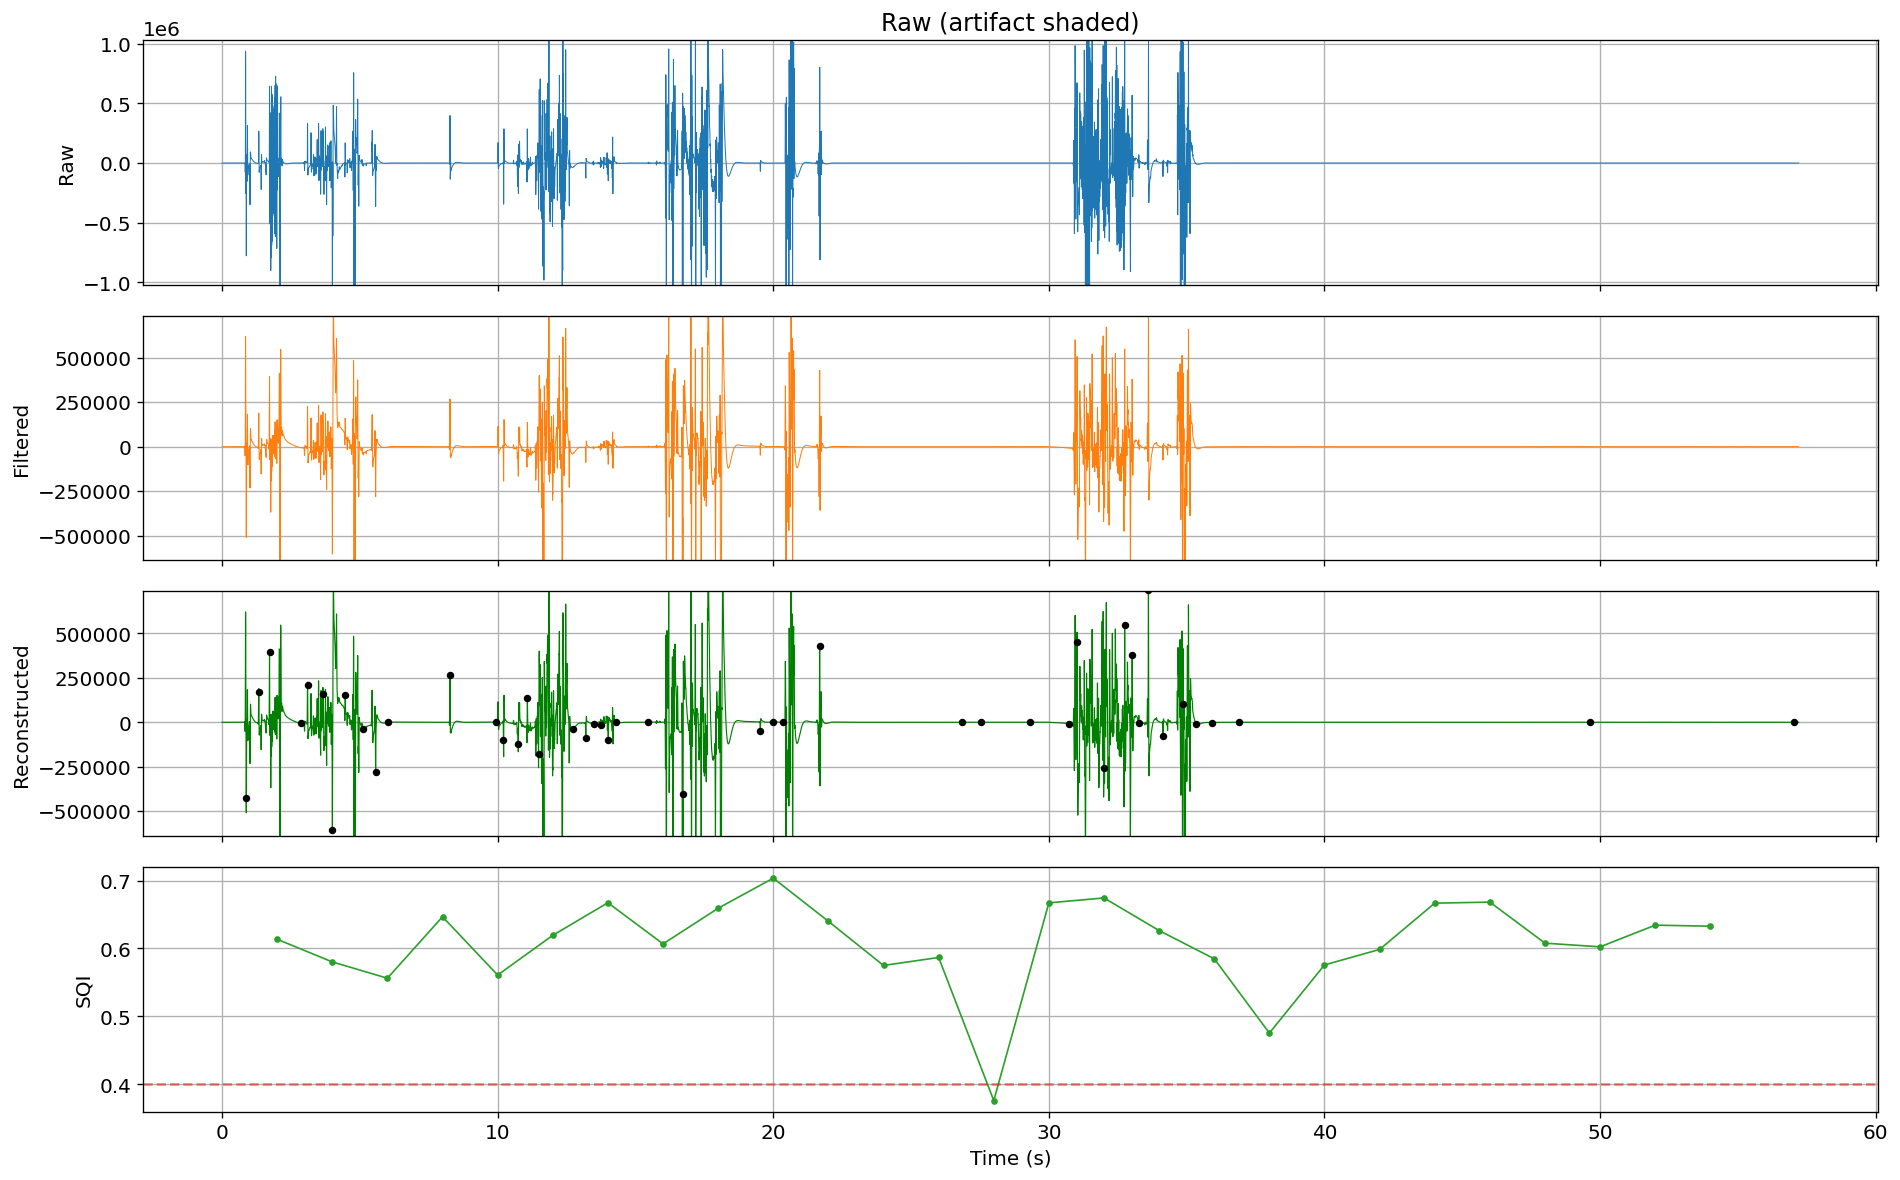

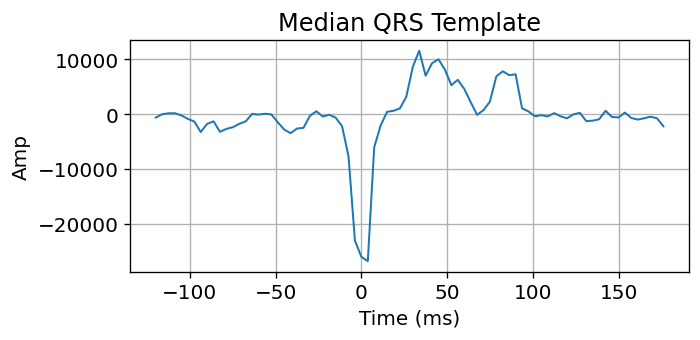

Beats: total=57, cleaned=57, template_len=80


In [65]:
# Section: Robust Artifact-Resilient Visualization
"""Composite visualization integrating:
1. Raw with artifact shading
2. Filtered signal
3. Reconstructed (long-gap PCHIP + template)
4. SQI timeline with threshold
Assumes helper functions already executed earlier.
"""
import numpy as np

if 'filt' in globals() and filt is not None:
    # Artifact mask (recompute to ensure sync with current cfg/raw)
    art_mask_viz = detect_artifacts(raw, cfg.fs, cfg) if getattr(cfg,'artifact_enable', False) else None
    lead_view = 1 if filt.shape[1] > 1 else 0
    # SQI (reuse or compute)
    if 'get_or_make_sqi' in globals():
        sqi_t, sqi_v = get_or_make_sqi(filt, cfg.fs, cfg)
    else:
        sqi_t, sqi_v = np.array([]), np.array([])
    # Peak detection & SQI filtering (robust)
    if 'detect_r_peaks_robust' in globals():
        det_sig_full = filt[:,lead_view]
        if art_mask_viz is not None and art_mask_viz.any():
            det_sig_full = _linear_inpaint(det_sig_full.copy(), art_mask_viz)
        peaks_all = detect_r_peaks_robust(
            det_sig_full, cfg.fs,
            band_lo=getattr(cfg, 'detect_band_lo', 5.0),
            band_hi=getattr(cfg, 'detect_band_hi', 20.0),
            order=getattr(cfg, 'detect_order', 2),
            integrate_ms=getattr(cfg, 'detect_integrate_ms', 150),
            k=getattr(cfg, 'detect_k', 3.0),
            min_rr_ms=getattr(cfg, 'detect_min_rr_ms', 250),
            art_mask=art_mask_viz
        )
        peaks_clean = filter_r_peaks_with_sqi(peaks_all, sqi_t, sqi_v, cfg.fs, 0.4) if sqi_t.size else peaks_all
    else:
        peaks_all = peaks_clean = np.array([])
    # Build template from clean beats
    template, pre = build_qrs_template(filt, peaks_clean, cfg.fs, lead_view)
    # Reconstruction pipeline
    rec_signal = filt[:,lead_view].copy()
    if art_mask_viz is not None and art_mask_viz.any():
        # Long-gap PCHIP inpainting first
        rec_signal = inpaint_long_artifacts(rec_signal, art_mask_viz, cfg.fs, 300.0)
        # Template based beat replacement (only where artifacts)
        if template.size:
            rec_signal = reconstruct_with_template(filt, peaks_clean, template, pre, cfg.fs, art_mask_viz, lead_view)
    # Visualization
    import matplotlib.pyplot as plt
    t = np.arange(len(rec_signal))/cfg.fs
    fig, axes = plt.subplots(4,1, figsize=(16,10), sharex=True)
    # 1. Raw + shading
    axes[0].plot(t, raw[:,lead_view], lw=0.6, color='#1f77b4'); axes[0].set_ylabel('Raw')
    if art_mask_viz is not None and art_mask_viz.any():
        on=False; s=0
        for i,fm in enumerate(art_mask_viz):
            if fm and not on:
                on=True; s=i
            if on and (not fm or i==len(art_mask_viz)-1):
                e=i if not fm else i+1
                axes[0].axvspan(s/cfg.fs,(e-1)/cfg.fs,color='red',alpha=0.05)
                on=False
    # widen y-limit (raw) using percentile + stronger padding
    raw_seg = raw[:,lead_view]
    if raw_seg.size > 10:
        rl, rh = np.nanpercentile(raw_seg, [1, 99])
        pad = 0.40 * (rh - rl) if np.isfinite(rh - rl) else 0.0
        if pad == 0:
            pad = max(1e-3, 0.08 * (abs(rh) + abs(rl) + 1e-6))
        axes[0].set_ylim(rl - pad, rh + pad)
    axes[0].set_title('Raw (artifact shaded)')
    # 2. Filtered
    axes[1].plot(t, filt[:,lead_view], lw=0.6, color='#ff7f0e'); axes[1].set_ylabel('Filtered')
    if filt.shape[0] > 10:
        fl2, fh2 = np.nanpercentile(filt[:,lead_view], [1, 99])
        pad2 = 0.40 * (fh2 - fl2) if np.isfinite(fh2 - fl2) else 0.0
        if pad2 == 0:
            pad2 = max(1e-3, 0.08 * (abs(fh2) + abs(fl2) + 1e-6))
        axes[1].set_ylim(fl2 - pad2, fh2 + pad2)
    # 3. Reconstructed + peaks
    axes[2].plot(t, rec_signal, lw=0.7, color='green'); axes[2].set_ylabel('Reconstructed')
    if rec_signal.size > 10:
        fl3, fh3 = np.nanpercentile(rec_signal, [1, 99])
        pad3 = 0.40 * (fh3 - fl3) if np.isfinite(fh3 - fl3) else 0.0
        if pad3 == 0:
            pad3 = max(1e-3, 0.08 * (abs(fh3) + abs(fl3) + 1e-6))
        axes[2].set_ylim(fl3 - pad3, fh3 + pad3)
    if 'peaks_clean' in globals() and isinstance(peaks_clean, np.ndarray) and peaks_clean.size:
        axes[2].scatter(peaks_clean/cfg.fs, rec_signal[peaks_clean], s=12, c='k', zorder=3)
    # 4. SQI timeline
    axes[3].set_ylabel('SQI'); axes[3].set_xlabel('Time (s)')
    if sqi_t.size:
        axes[3].plot(sqi_t, sqi_v, marker='o', ms=3, lw=1, color='C2')
        axes[3].axhline(0.4, color='r', ls='--', alpha=0.5)
    else:
        axes[3].text(0.5,0.5,'No SQI', ha='center', va='center')
    plt.tight_layout(); plt.show()
    if template.size:
        plt.figure(figsize=(6,3));
        tt = (np.arange(template.size)-pre)/cfg.fs*1000.0
        plt.plot(tt, template, lw=1.2); plt.title('Median QRS Template'); plt.xlabel('Time (ms)'); plt.ylabel('Amp'); plt.tight_layout(); plt.show()
    print(f'Beats: total={len(peaks_all)}, cleaned={len(peaks_clean)}, template_len={template.size}')
else:
    print('Filtered signal not available.')

In [66]:
# (Optional) Export reconstructed signal & artifact ratio
import os, csv, numpy as np
if 'rec_signal' in globals():
    out_dir = 'out/signals'
    os.makedirs(out_dir, exist_ok=True)
    # Artifact ratio series if available
    if 'compute_artifact_ratio_series' in globals() and 'detect_artifacts' in globals() and 'raw' in globals():
        art_mask_export = detect_artifacts(raw, cfg.fs, cfg) if getattr(cfg,'artifact_enable', False) else None
        if art_mask_export is not None:
            win_sec = getattr(cfg, 'sqi_window_sec', 5.0)
            step_sec = getattr(cfg, 'sqi_window_step', win_sec/2.0)
            ar_t, ar_v = compute_artifact_ratio_series(art_mask_export, cfg.fs, win_sec, step_sec)
        else:
            ar_t, ar_v = np.array([]), np.array([])
    else:
        ar_t, ar_v = np.array([]), np.array([])
    # Save reconstructed lead as CSV (time, value)
    rec_path = os.path.join(out_dir, 'reconstructed_lead.csv')
    with open(rec_path, 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['time_sec','reconstructed'])
        for i,v in enumerate(rec_signal):
            w.writerow([i/cfg.fs, v])
    if ar_t.size:
        ar_path = os.path.join(out_dir, 'artifact_ratio.csv')
        with open(ar_path, 'w', newline='') as f:
            w = csv.writer(f); w.writerow(['time_center_sec','artifact_ratio'])
            for t_,v_ in zip(ar_t, ar_v):
                w.writerow([t_, v_])
    print('Exported:', rec_path, 'and' if ar_t.size else '(no artifact ratio series)', 'artifact_ratio.csv' if ar_t.size else '')
else:
    print('Reconstructed signal not present; run the visualization cell first.')

Exported: out/signals/reconstructed_lead.csv (no artifact ratio series) 


In [67]:
# Section: Robust R-peak Detector (Pan-Tompkins-like)
import numpy as np
from scipy.signal import butter, sosfiltfilt, find_peaks

def _mad_v(x):
    x = np.asarray(x)
    med = np.median(x)
    return np.median(np.abs(x - med))

def detect_r_peaks_robust(x, fs,
                          band_lo=5.0, band_hi=20.0, order=2,
                          integrate_ms=150, k=3.0, min_rr_ms=250,
                          art_mask=None):
    """
    Pan-Tompkins style detector with zero-phase bandpass, derivative-square-integrate,
    robust adaptive threshold, refractory, and local refinement on the bandpassed trace.
    - x: 1D ECG signal (cleaned/filtered preferred)
    - fs: sampling rate (Hz)
    - band_lo/hi: detection band (Hz)
    - integrate_ms: moving average window (ms)
    - k: MAD-based threshold scaling (higher => fewer peaks)
    - min_rr_ms: refractory period (ms)
    - art_mask: optional boolean mask; peaks inside artifact-dominated samples are pruned
    Returns: np.ndarray[int] sample indices of R-peaks
    """
    if x is None or len(x) < 5:
        return np.array([], dtype=int)
    nx = np.asarray(x).astype(float)
    # Zero-phase bandpass
    wn = [band_lo/(fs/2.0), band_hi/(fs/2.0)]
    wn[0] = max(0.001, min(0.99, wn[0]))
    wn[1] = max(wn[0] + 1e-3, min(0.999, wn[1]))
    sos = butter(order, wn, btype='bandpass', output='sos')
    bp = sosfiltfilt(sos, nx)
    # Derivative, square
    dx = np.diff(bp, prepend=bp[0])
    y = dx * dx
    # Moving integration
    win = max(1, int(round(integrate_ms * fs / 1000.0)))
    kern = np.ones(win) / win
    integ = np.convolve(y, kern, mode='same')
    # Robust threshold
    mad = _mad_v(integ)
    thr = np.median(integ) + (k * 1.4826 * mad)
    # Refractory distance
    distance = max(1, int(round(min_rr_ms * fs / 1000.0)))
    peaks, props = find_peaks(integ, height=thr, distance=distance)
    if peaks.size == 0:
        return peaks
    # Optional artifact filtering
    if art_mask is not None and np.any(art_mask):
        pad = max(1, win // 2)
        keep = []
        for p in peaks:
            a = max(0, p - pad)
            b = min(len(art_mask), p + pad + 1)
            if not np.any(art_mask[a:b]):
                keep.append(True)
            else:
                keep.append(False)
        peaks = peaks[np.array(keep, dtype=bool)]
        if peaks.size == 0:
            return peaks
    # Local refinement to the bandpassed maxima (±80 ms)
    refine = max(1, int(round(0.08 * fs)))
    refined = []
    for p in peaks:
        a = max(0, p - refine)
        b = min(len(bp), p + refine + 1)
        # use absolute peak to handle inverted QRS
        loc = a + int(np.argmax(np.abs(bp[a:b])))
        refined.append(loc)
    refined = np.unique(np.array(refined, dtype=int))
    # Enforce refractory again after refinement (to collapse duplicates)
    if refined.size:
        refined = refined[np.argsort(refined)]
        pruned = [refined[0]]
        for idx in refined[1:]:
            if (idx - pruned[-1]) >= distance:
                pruned.append(idx)
            else:
                # keep the one with larger |bp|
                if abs(bp[idx]) > abs(bp[pruned[-1]]):
                    pruned[-1] = idx
        refined = np.array(pruned, dtype=int)
    return refined

print('Robust R-peak detector (Pan-Tompkins-like) ready.')

Robust R-peak detector (Pan-Tompkins-like) ready.


In [68]:
# Section: SWT-based Denoising and R-peak Detection
"""
Implements Stationary Wavelet Transform (SWT) denoising and SWT-based R-peak detection.
- Wavelet: default 'coif2' per paper rationale (short length, good QRS affinity)
- Levels: auto-selects levels whose pseudo-bands overlap QRS (≈5–40 Hz) based on fs
- Threshold: fixed fraction of per-level max (default 0.5), hard thresholding
- Detector: uses abs(detail) on selected level(s), MAD adaptive threshold, refractory, artifact pruning, local refinement
Robustness improvements:
- Auto-pad signal to the nearest multiple of 2**level for SWT, then trim back to original length
- Guard against empty/zero max_level and empty band lists
"""
import numpy as np
from scipy.signal import butter, sosfiltfilt, find_peaks

try:
    import pywt
    _PYWT_AVAILABLE = True
except Exception:
    _PYWT_AVAILABLE = False

_QRS_BAND = (5.0, 40.0)

def _swt_level_bands(fs, max_level):
    if max_level < 1:
        return []
    bands = []
    for j in range(1, max_level+1):
        # SWT/DWT detail j corresponds approx to (fs/2^{j+1}, fs/2^{j})
        f_low = fs / (2**(j+1))
        f_high = fs / (2**j)
        bands.append((f_low, f_high))
    return bands  # list of tuples length=max_level

def _choose_swt_levels(fs, max_level=6, target=_QRS_BAND):
    if max_level < 1:
        return [], []
    bands = _swt_level_bands(fs, max_level)
    use = []
    for j,(fl,fh) in enumerate(bands, start=1):
        # overlap test with target band
        if not (fh < target[0] or fl > target[1]):
            use.append(j)
    if not use:
        # pick level with band center closest to target center
        tc = 0.5*(target[0]+target[1])
        centers = [0.5*(fl+fh) for (fl,fh) in bands]
        if len(centers) == 0:
            return [], bands
        j = int(np.argmin([abs(c-tc) for c in centers])) + 1
        use = [j]
    return use, bands

def _pad_to_swt_length(x, level):
    """Pad the 1D array x at the end so that len(x) is a multiple of 2**level."""
    if level < 1:
        return x, 0
    n = len(x)
    pow2 = 2**level
    pad = (pow2 - (n % pow2)) % pow2
    if pad:
        x_pad = np.pad(x, (0, pad), mode='edge')
    else:
        x_pad = x
    return x_pad, pad

def swt_denoise_ecg(x, wavelet='coif2', level=None, fixed_thr=0.5, mode='hard'):
    if not _PYWT_AVAILABLE:
        raise RuntimeError('PyWavelets (pywt) not available. Install pywt to use SWT.')
    x = np.asarray(x, dtype=float)
    # pick max level allowed by pywt.swt_max_level
    max_lev = pywt.swt_max_level(len(x))
    lev = level or min(6, max_lev)
    if lev < 1:
        # Nothing to do
        return x.copy()
    x_pad, pad = _pad_to_swt_length(x, lev)
    coeffs = pywt.swt(x_pad, wavelet, level=lev, start_level=0, trim_approx=False)
    # coeffs is list of (cA, cD)
    den = []
    for cA, cD in coeffs:
        thr = float(fixed_thr) * (np.nanmax(np.abs(cD)) + 1e-12)
        if mode == 'hard':
            cD_f = np.where(np.abs(cD) >= thr, cD, 0.0)
        else:
            # soft
            cD_f = np.sign(cD) * np.maximum(np.abs(cD) - thr, 0.0)
        den.append((cA, cD_f))
    x_den_pad = pywt.iswt(den, wavelet)
    if pad:
        x_den = x_den_pad[:len(x)]
    else:
        x_den = x_den_pad
    return np.asarray(x_den)

def swt_detect_r_peaks(x, fs,
                       wavelet='coif2', max_level=6, use_levels=None,
                       fixed_thr=0.5, integrate_ms=120, k=3.0, min_rr_ms=250,
                       art_mask=None, refine_bp=(5.0,20.0), refine_win_ms=80):
    if not _PYWT_AVAILABLE:
        return np.array([], dtype=int)
    x = np.asarray(x, dtype=float)
    n0 = len(x)
    # determine feasible level and pad accordingly
    max_lev = min(max_level, pywt.swt_max_level(n0))
    if max_lev < 1:
        return np.array([], dtype=int)
    x_pad, pad = _pad_to_swt_length(x, max_lev)
    if art_mask is not None:
        art_mask = np.asarray(art_mask, dtype=bool)
        if pad:
            art_mask = np.pad(art_mask, (0, pad), constant_values=False)
    if use_levels is None:
        use_levels, _ = _choose_swt_levels(fs, max_level=max_lev, target=_QRS_BAND)
        if not use_levels:
            return np.array([], dtype=int)
    coeffs = pywt.swt(x_pad, wavelet, level=max_lev, start_level=0, trim_approx=False)
    # Build detection energy from selected detail levels
    energy = np.zeros_like(x_pad, dtype=float)
    for j,(cA,cD) in enumerate(coeffs, start=1):
        if j in use_levels:
            # per-level hard threshold with fixed fraction
            thr = float(fixed_thr) * (np.nanmax(np.abs(cD)) + 1e-12)
            cD_f = np.where(np.abs(cD) >= thr, cD, 0.0)
            energy += np.abs(cD_f)
    # integrate/smooth
    win = max(1, int(round(integrate_ms * fs / 1000.0)))
    if win > 1:
        kern = np.ones(win)/win
        integ = np.convolve(energy, kern, mode='same')
    else:
        integ = energy
    # MAD adaptive threshold
    med = np.median(integ)
    mad = np.median(np.abs(integ - med))
    thr = med + (k * 1.4826 * (mad + 1e-12))
    distance = max(1, int(round(min_rr_ms * fs / 1000.0)))
    peaks, _ = find_peaks(integ, height=thr, distance=distance)
    if peaks.size == 0:
        return peaks
    # trim peaks that fall in the padded tail
    peaks = peaks[peaks < n0]
    if peaks.size == 0:
        return peaks
    # Artifact pruning around peaks
    if art_mask is not None and np.any(art_mask):
        pad_w = max(1, win//2)
        keep = []
        for p in peaks:
            a = max(0, p - pad_w)
            b = min(len(art_mask), p + pad_w + 1)
            keep.append(not np.any(art_mask[a:b]))
        peaks = peaks[np.array(keep, dtype=bool)]
        if peaks.size == 0:
            return peaks
    # Local refinement on bandpassed signal to align with R apex
    if refine_bp is not None and peaks.size:
        lo, hi = refine_bp
        wn = [lo/(fs/2.0), hi/(fs/2.0)]
        wn[0] = max(0.001, min(0.99, wn[0])); wn[1] = max(wn[0]+1e-3, min(0.999, wn[1]))
        sos = butter(2, wn, btype='bandpass', output='sos')
        bp = sosfiltfilt(sos, x_pad)
        refine = max(1, int(round(refine_win_ms * fs / 1000.0)))
        refined = []
        for p in peaks:
            a = max(0, p - refine)
            b = min(len(bp), p + refine + 1)
            loc = a + int(np.argmax(np.abs(bp[a:b])))
            refined.append(loc)
        peaks = np.unique(np.array(refined, dtype=int))
        # enforce refractory after refinement
        peaks = np.sort(peaks)
        if peaks.size:
            pruned = [peaks[0]]
            for idx in peaks[1:]:
                if (idx - pruned[-1]) >= distance:
                    pruned.append(idx)
                else:
                    if abs(bp[idx]) > abs(bp[pruned[-1]]):
                        pruned[-1] = idx
            peaks = np.array(pruned, dtype=int)
        # trim any refined peaks that landed in padded region
        peaks = peaks[peaks < n0]
    return peaks

print('SWT helpers ready:', 'pywt OK' if _PYWT_AVAILABLE else 'pywt MISSING')

SWT helpers ready: pywt OK


In [69]:
# Section: SWT-based Denoise and R-peak Detection
import numpy as np
try:
    import pywt
except Exception as _e:
    pywt = None
    print('PyWavelets not available; install pywt to enable SWT features. Error:', _e)

_DEF_WAVELET = 'coif2'

def _mad_arr(x):
    x = np.asarray(x)
    med = np.median(x)
    return np.median(np.abs(x - med))

def _pad_to_swt_length(x, level):
    """Pad 1D array x at the end so len(x) is a multiple of 2**level."""
    if level is None or level < 1:
        return np.asarray(x), 0
    x = np.asarray(x)
    n = len(x)
    pow2 = 2**level
    pad = (pow2 - (n % pow2)) % pow2
    if pad:
        x_pad = np.pad(x, (0, pad), mode='edge')
    else:
        x_pad = x
    return x_pad, pad

def recommend_swt_level(fs, prefer_level=4, target_fc=17.0, max_level=None, n_samples=None):
    """Choose SWT level whose nominal center freq fc≈fs/2^(l+0.5) is closest to target_fc.
    Fallback to prefer_level if inputs are insufficient.
    """
    if fs is None or fs <= 0:
        return prefer_level
    # If length known and pywt available, honor max swt level
    if pywt is not None and n_samples is not None:
        try:
            max_level_auto = pywt.swt_max_level(n_samples)
            if max_level is None:
                max_level = max_level_auto
            else:
                max_level = min(max_level, max_level_auto)
        except Exception:
            pass
    if max_level is None:
        max_level = max(1, prefer_level)
    best_l = 1
    best_err = float('inf')
    for l in range(1, max_level+1):
        fc = fs / (2.0 ** (l + 0.5))
        err = abs(fc - target_fc)
        if err < best_err:
            best_err = err
            best_l = l
    return best_l

def swt_denoise(x, wavelet=_DEF_WAVELET, levels=4, thr=0.5, thr_mode='mad', hard=True):
    """SWT denoise: hard-threshold all detail coeffs at each level.
    thr_mode='mad' means threshold = thr * 1.4826 * MAD(detail). If thr_mode='abs', uses absolute thr.
    Returns denoised signal and list of (cA, cD) after thresholding.
    """
    if pywt is None:
        return np.asarray(x), []
    x = np.asarray(x)
    # Ensure feasible level and valid length by padding
    try:
        max_lev = max(0, pywt.swt_max_level(len(x)))
    except Exception:
        max_lev = 0
    levels = int(min(levels, max_lev)) if max_lev > 0 else 0
    if levels < 1:
        return x.copy(), []
    x_pad, pad = _pad_to_swt_length(x, levels)
    coeffs = pywt.swt(x_pad, wavelet, level=levels)
    th_coeffs = []
    for (cA, cD) in coeffs:
        if thr_mode == 'mad':
            sigma = 1.4826 * _mad_arr(cD)
            t = thr * sigma
        else:
            t = thr
        if hard:
            cD_f = np.where(np.abs(cD) >= t, cD, 0.0)
        else:
            cD_f = np.sign(cD) * np.maximum(np.abs(cD) - t, 0.0)
        th_coeffs.append((cA, cD_f))
    x_rec_pad = pywt.iswt(th_coeffs, wavelet)
    x_rec = x_rec_pad[:len(x)] if pad else x_rec_pad
    return x_rec, th_coeffs

def detect_r_peaks_swt(x, fs,
                       wavelet=_DEF_WAVELET, levels=4, target_level=None,
                       integrate_ms=120, k=3.0, min_rr_ms=250,
                       art_mask=None):
    """SWT-based adaptive R-peak detector.
    Safe for arbitrary window lengths via padding; returns indices in original (unpadded) domain.
    """
    if x is None or pywt is None:
        return np.array([], dtype=int)
    x = np.asarray(x, dtype=float)
    n0 = len(x)
    # Determine feasible levels and pad
    try:
        max_lev = max(0, pywt.swt_max_level(n0))
    except Exception:
        max_lev = 0
    levels = int(min(levels, max_lev)) if max_lev > 0 else 0
    if levels < 1:
        return np.array([], dtype=int)
    x_pad, pad = _pad_to_swt_length(x, levels)
    coeffs = pywt.swt(x_pad, wavelet, level=levels)
    # Determine target level
    if target_level is None:
        target_level = recommend_swt_level(fs, prefer_level=levels, n_samples=len(x_pad))
    target_level = int(max(1, min(levels, target_level)))
    # coeffs are [(A1,D1),...,(AL,DL)], target_level -> D_target
    cA_t, cD_t = coeffs[target_level-1]
    qrs_sig = cD_t
    # Energy envelope
    win = max(1, int(round(integrate_ms * fs / 1000.0)))
    env = np.convolve(np.abs(qrs_sig)**2, np.ones(win)/win, mode='same')
    # Threshold
    sigma = 1.4826 * _mad_arr(env)
    thr = np.median(env) + k * sigma
    from scipy.signal import find_peaks
    distance = max(1, int(round(min_rr_ms * fs / 1000.0)))
    peaks, _ = find_peaks(env, height=thr, distance=distance)
    if peaks.size == 0:
        return peaks
    # If padded, drop peaks beyond original length
    peaks = peaks[peaks < n0]
    if peaks.size == 0:
        return peaks
    # Artifact pruning (±win/2 neighborhood)
    if art_mask is not None and np.any(art_mask):
        art_mask = np.asarray(art_mask, dtype=bool)
        if pad:
            art_mask = np.pad(art_mask, (0, pad), constant_values=False)
        pad_w = max(1, win // 2)
        keep = []
        for p in peaks:
            a = max(0, p - pad_w)
            b = min(len(art_mask), p + pad_w + 1)
            keep.append(not np.any(art_mask[a:b]))
        peaks = peaks[np.array(keep, dtype=bool)]
        if peaks.size == 0:
            return peaks
    # Local refinement on |qrs_sig| within ±80ms
    refine = max(1, int(round(0.08 * fs)))
    refined = []
    for p in peaks:
        a = max(0, p - refine)
        b = min(len(qrs_sig), p + refine + 1)
        loc = a + int(np.argmax(np.abs(qrs_sig[a:b])))
        refined.append(loc)
    refined = np.unique(np.array(refined, dtype=int))
    # Enforce refractory again after refinement
    if refined.size:
        refined = refined[np.argsort(refined)]
        pruned = [refined[0]]
        for idx in refined[1:]:
            if (idx - pruned[-1]) >= distance:
                pruned.append(idx)
            else:
                if abs(qrs_sig[idx]) > abs(qrs_sig[pruned[-1]]):
                    pruned[-1] = idx
        refined = np.array(pruned, dtype=int)
    # Drop refined peaks beyond original length
    refined = refined[refined < n0]
    return refined

print('SWT denoise + detector ready (wavelet=coif2).')

SWT denoise + detector ready (wavelet=coif2).


### Interactive Explorer Launcher
간단 실행: 아래 셀을 실행하면 상단의 인터랙티브 뷰어가 즉시 표시됩니다. 커널 재시작 후에는 설정/처리 셀들을 먼저 실행한 뒤 이 셀을 실행하세요.

In [70]:
# Re-display the Interactive Explorer UI
try:
    # Find a display function/object if defined in the interactive explorer cell
    # Here we simply re-execute the explorer cell logic if symbols are present
    import ipywidgets as widgets
    if 'file_dd' in globals() and 'lead_dd' in globals() and 'method_dd' in globals() and 'out' in globals():
        display(widgets.VBox([widgets.HBox([file_dd, lead_dd, method_dd]), widgets.HBox([t_range]), widgets.HBox([show_artf_supp, show_artf_mask]), out]))
    else:
        # Fallback: try to locate and re-run the explorer setup if available
        print('Interactive explorer not initialized in this session. Please run the explorer setup cell above (Section 12).')
except Exception as e:
    print('Could not display interactive explorer:', e)

## Data sanity check: why do some TXT waveforms look broken?

This section inspects TXT files under `datasets/` and tries a robust parse (delimiter inference, optional time/index column handling, decimal point issues), then shows quick diagnostics and a short plot. Use it to find why certain files look corrupted (e.g., wrong delimiter, header rows, units/scale, or dropping the wrong first column).

In [ ]:
# SC-1) Robust TXT reader and quick diagnostics
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import re


def infer_delim(sample_path: Path, max_lines: int = 5):
    cand = {'\t': 'tab', ',': 'comma', ';': 'semi', ' ': 'space'}
    text = ''.join(sample_path.read_text(errors='ignore').splitlines(True)[:max_lines])
    counts = {d: text.count(d) for d in cand}
    # prefer tab/comma/semi if counts comparable; space can be noisy
    ordered = sorted(counts.items(), key=lambda kv: kv[1], reverse=True)
    for d, c in ordered:
        if c > 0 and d != ' ':
            return d
    return '\t' if counts.get('\t', 0) else ','


def try_read_txt(path: Path):
    # 1) pick delimiter
    delim = infer_delim(path)
    # 2) load with genfromtxt, skipping obvious header rows
    arr = np.genfromtxt(path, delimiter=delim, dtype=np.float64)
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    # drop rows that are all NaN (headers or footers)
    row_ok = ~np.all(np.isnan(arr), axis=1)
    arr = arr[row_ok]
    # drop columns that are all NaN
    col_ok = ~np.all(np.isnan(arr), axis=0)
    arr = arr[:, col_ok]
    # if first column looks like time/index, drop it
    if arr.shape[1] > 1:
        col0 = arr[:, 0]
        finite = np.isfinite(col0)
        if finite.sum() > 5:
            d = np.diff(col0[finite])
            if np.all(d >= 0) and np.median(d) > 0:
                arr = arr[:, 1:]
    arr = np.nan_to_num(arr, nan=0.0)
    # ensure 12 columns by crop/pad
    c = arr.shape[1]
    if c >= 12:
        arr = arr[:, :12]
    else:
        pad = np.zeros((arr.shape[0], 12 - c), dtype=arr.dtype)
        arr = np.concatenate([arr, pad], axis=1)
    return arr.astype('float32'), delim


def zscore_12(x: np.ndarray, eps: float = 1e-6):
    m = x.mean(axis=0, keepdims=True)
    s = x.std(axis=0, keepdims=True)
    return (x - m) / (s + eps)


def quick_plot_compare(paths: list[Path], fs: float = 257.0, secs: float = 5.0):
    n = min(3, len(paths))
    fig, axes = plt.subplots(n, 1, figsize=(12, 2.5 * n), sharex=True)
    if n == 1:
        axes = [axes]
    for i, p in enumerate(paths[:n]):
        x, d = try_read_txt(p)
        x = zscore_12(x)
        t = np.arange(min(len(x), int(fs * secs))) / fs
        axes[i].plot(t, x[:len(t), 0], label=f'{p.name} (lead0) [{"TAB" if d=="\t" else d}]')
        axes[i].legend(loc='upper right'); axes[i].grid(True)
    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout(); plt.show()


# Collect a few files including sgTest reference
root = Path('datasets')
files = sorted([p for p in root.glob('*.txt')])
ref = [p for p in files if 'sgTest_20191207_205933' in p.name]
others = [p for p in files if p not in ref]

print('Found', len(files), 'TXT files')
if ref:
    print('Reference:', ref[0].name)

# Diagnostics: print shape, delimiter, basic stats
for p in files[:5]:
    x, d = try_read_txt(p)
    m = float(np.mean(x)); s = float(np.std(x)); rng = float(np.ptp(x))
    print(f'- {p.name}: shape={x.shape}, delim={repr(d)}, mean={m:.3f}, std={s:.3f}, ptp={rng:.3f}')

# Quick overlay of first three to see which looks broken vs reference
subset = (ref[:1] + others[:2]) if ref else files[:3]
quick_plot_compare(subset, fs=257.0, secs=6.0)
